# IBKR Index Migration  and Optimal Trade Design
## From Event-Study Evidence to a Tradable Position

I analysed the abnormal return associated with IBKR migration from the S&P MidCap 400 to the S&P 500 using a PCA analysis and dimensionality reduction. Now, from a backward-looking point of view, I would like to answer the following question:

> **Conditional on the estimated event-return distribution, what position would the trade-design framework imply after accounting for risk, transaction costs, liquidity and portfolio constraints?**

The analysis should be focused on the primary tradeable event window:

$$
\text{26 August 2025 open}
\rightarrow
\text{27 August 2025 close}
$$

The event-study output is an abnormal return:

$$
AR_t
=
r_t^{IBKR}
-
\widehat r_t^{IBKR}
$$

where $\widehat r_t^{IBKR}$ is the return predicted by the PCA regression using contemporaneous donor-stock movements, the trade-design model then translates an uncertain return distribution into a signed optimal position:

$$
\boxed{
\text{Event-return distribution}
\rightarrow
\text{Tradable strategy}
\rightarrow
\text{Costs and liquidity}
\rightarrow
\text{Risk constraints}
\rightarrow
q^*
}
$$

## 1. Research Scope 

The focus of the research question is retrospective and the event-study model itself is an ex-post counterfactual: contemporaneous donor returns are used to estimate how IBKR would normally have moved during the event. For this reason, the estimated abnormal-return distribution should not be interpreted as a return forecast that was available before trading began on 26 August. On the other hand, the question answered here is:

> **If the event-effect distribution estimated ex post is treated as the investment opportunity, what trade would the optimization framework imply?**

Which is fundamentally different from asking what position could an investor have known to take before the event. An ex-ante trading model would require historical index-migration events or another forecasting model trained and estimated entirely from information available before the trade.

## 2. From Abnormal Return to a Tradable Strategy

The event-study output is an **abnormal return**, not directly the return of a naked IBKR position. The difference is key to understand how the optimal trade design is built. In fact, a naked IBKR position earns:

$$
r_t^{IBKR}
$$

while the event study estimates:

$$
AR_t
=
r_t^{IBKR}
-
\widehat r_t^{IBKR}
$$

The focus here is about trading the residual component approximately, the IBKR exposure must therefore be combined with a hedge representing the PCA counterfactual. Define a residual strategy normalized to one dollar of IBKR target exposure:

$$
R_t^{res}
\approx
r_t^{IBKR}
-
r_t^{hedge}
$$

The hedge will be derived from the estimated PCA regression, the signed trade notional is:

$$
q\in\mathbb R
$$

And the convention is:

$$
q>0
$$

means **long IBKR residual exposure**:

$$
\text{long IBKR}
+
\text{short counterfactual hedge}
$$

while:

$$
q<0
$$

means **short IBKR residual exposure**:

$$
\text{short IBKR}
+
\text{long counterfactual hedge}
$$

The direction of the trade is not determined in advance, but it is rather defined by the optimizer later in the analysis.

## 3. Notebook Architecture

This notebook connects two pieces of research that I have previously completed.

The **IBKR event-study notebook** provides:

- the event-effect distribution
- the primary tradeable event window
- the close-to-close and open-to-close PCA regressions
- the donor universe
- pre-event market data needed for liquidity estimation

The **optimal-trade-design notebook** provides the generic position-sizing framework:

$$
q^*
=
g(
\text{return distribution},
\text{costs},
\text{liquidity},
\text{investor policy}
)
$$

Importantly, this part of the research will not refit the PCA model and will not repeat the theoretical derivation of the optimizer.

Instead, it will:

1. construct an explicit handoff from the event study
2. convert the PCA counterfactual into tradable hedge exposures
3. construct the strategy-return distribution
4. estimate implementation costs and pre-trade liquidity
5. specify investor-policy inputs separately
6. calculate the optimal signed position and its uncertainty
7. translate the result into IBKR and hedge-leg notionals

In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42
rng = np.random.default_rng(
    RANDOM_SEED
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

pd.options.display.float_format = (
    '{:,.4f}'.format
)

np.set_printoptions(
    precision=4,
    suppress=True,
)


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

plt.style.use(
    'dark_background'
)

plt.rcParams[
    'figure.figsize'
] = (12, 6)

plt.rcParams[
    'font.size'
] = 11

plt.rcParams[
    'axes.grid'
] = True

plt.rcParams[
    'grid.alpha'
] = 0.2


print(
    'Environment configured.'
)

print(
    f'Random seed: {RANDOM_SEED}'
)

Environment configured.
Random seed: 42


In [34]:
# ============================================================
# APPLICATION CONFIGURATION
# ============================================================

TARGET = 'IBKR'

PRIMARY_EVENT_WINDOW = (
    'primary_tradeable'
)

TRADE_OBJECT = (
    'PCA_residual'
)


application_config = {
    'target':
        TARGET,

    'primary_event_window':
        PRIMARY_EVENT_WINDOW,

    'trade_object':
        TRADE_OBJECT,

    'event_study_interpretation':
        'ex_post_counterfactual',

    'optimizer_position_unit':
        'USD_IBKR_target_leg_notional',
}


display(
    pd.Series(
        application_config
    )
)

target                                                IBKR
primary_event_window                     primary_tradeable
trade_object                                  PCA_residual
event_study_interpretation          ex_post_counterfactual
optimizer_position_unit       USD_IBKR_target_leg_notional
dtype: object

## 5. Required Event-Study Handoff

The fundamental purpose of this section is to **bring the important outputs of that previous notebook into this one in a reproducible way**.

A saved `.ipynb` file contains code and displayed outputs, but it does not preserve the live Python objects that existed while the notebook was running. For example, the fitted scaler, PCA model, regression model, residual arrays and bootstrap draws are not automatically available in this last piece of research.

Therefore, the previous notebook exports a handoff containing the numerical information needed to reconstruct the event-study model exactly, this will enable me to perform the analysis required by the research question.

The handoff includes:

- the exact donor-stock order
- scaler means and standard deviations
- PCA means and component loadings
- PCR regression coefficients and intercepts
- historical model residuals
- bootstrap event-effect draws
- event-window outputs
- relevant market data

The donor order is especially important, the model expects the donor-return vector in a fixed order:

$$
x_t =
\begin{bmatrix}
r_{\text{SCHW},t} \\
r_{\text{HOOD},t} \\
\vdots \\
r_{\text{VIRT},t}
\end{bmatrix}
$$

If the order changed while the coefficients stayed the same, the code would still run, but each coefficient would be applied to the wrong stock.

### Statistical object carried forward

The previous notebook estimated IBKR's abnormal return as:

$$
AR_t
=
r_t^{\text{IBKR}}
-
\widehat r_t^{\text{IBKR}}
$$

where:

- $r_t^{\text{IBKR}}$ is the return actually observed for IBKR
- $\widehat r_t^{\text{IBKR}}$ is the return predicted by the PCA/PCR counterfactual model

For the primary event window, the estimated abnormal simple return is approximately:

$$
-5.24\%
$$

This means that IBKR performed about 5.24% worse than the return predicted by the frozen counterfactual model over that window, however, this is an **ex-post measurement**, not an ex-ante forecast. The calculation uses donor and IBKR returns observed during the event window this means that an investor standing at the beginning of the event did not know this abnormal return in advance. The question in this notebook is instead:

> Given the event effect that we measured afterwards, how would a trading model translate that effect into an implementable position?

### Uncertainty in the measured event effect

The event-study notebook also exported an uncertainty distribution, the key idea is that the counterfactual model is not perfect and even during normal historical periods, actual IBKR returns differ from model predictions. A historical residual is:

$$
e_t
=
r_t^{\text{IBKR}}
-
\widehat r_t^{\text{IBKR}}
$$

These residuals tell us how large the model's normal prediction errors can be. Since the event window contains two return legs, the research constructs historical two-session residual blocks that match the event structure and there are 62 such historical blocks. For bootstrap draw $b$,

$$
e^{(b)}
$$

is one historical two-session model error. If the observed abnormal event return is:

$$
AR_{\text{event}}^{\log}
$$

then one possible event-effect draw is:

$$
AR_{\text{effect}}^{\log,(b)}
=
AR_{\text{event}}^{\log}
-
e^{(b)}
$$

The intuition is:

$$
\text{observed abnormal return}
=
\text{event effect}
+
\text{ordinary model error}
$$

Therefore:

$$
\text{event effect}
=
\text{observed abnormal return}
-
\text{model error}
$$

Repeating this procedure many times gives a distribution of plausible event effects. I then store 2,000 bootstrap draws, but these do **not** represent 2,000 independent historical observations, they are just repeated resamples from 62 underlying historical two-session residual blocks, so the true historical information remains limited. Finally, each log-return draw is converted to a simple return through:

$$
R^{(b)}
=
\exp\left(
AR_{\text{effect}}^{\log,(b)}
\right)-1
$$

because, for a log return,

$$
r^{\log}
=
\ln\left(\frac{P_1}{P_0}\right)
$$

and therefore:

$$
\frac{P_1}{P_0}-1
=
e^{r^{\log}}-1
$$

These event-effect draws will be transformed into the uncertainty distribution of the tradable residual strategy.

## 6. Build and Validate the Event-Study Handoff

I now have to check that the exported numerical information is sufficient to **reconstruct exactly the same PCA/PCR model**, this is important to make the trading-design research not dependent on hidden objects from my previous research. Basicually, I have to ask:

> If we only keep the exported scaler, PCA and regression parameters, can we reproduce the same predictions as the original frozen model?

### 6.1 Reconstruct the frozen PCA/PCR pipeline

The counterfactual model begins with the donor-stock return vector:

$$
x_t
$$

The first step is standardization.

For donor $j$:

$$
z_{j,t}
=
\frac{x_{j,t}-\mu_{s,j}}{s_j}
$$

where:

- $\mu_{s,j}$ is the training-sample mean of donor $j$
- $s_j$ is its training-sample standard deviation

In vector form:

$$
z_t
=
\frac{x_t-\mu_s}{s}
$$

with the division performed element by element, the purpose is to put all donor stocks on comparable scales. For example, if one stock is naturally much more volatile than another, PCA should not give it more importance only because its raw returns are numerically larger.

### 6.2 PCA transformation

The standardized returns are then transformed into principal-component scores:

$$
f_t
=
(z_t-\mu_{\text{PCA}})C^\top
$$

where:

- $C$ contains the PCA component directions
- $\mu_{\text{PCA}}$ is the mean stored by the fitted PCA object
- $f_t$ contains the principal-component scores

A principal component is simply a weighted combination of the standardized donor returns. For example:

$$
PC_1
=
0.30\,z_{\text{SCHW}}
+
0.10\,z_{\text{HOOD}}
+\cdots
$$

The model keeps only the first:

$$
K=2
$$

principal components.

### 6.3 PCR prediction

The PCR model then predicts IBKR's return using those two component scores:

$$
\widehat r_t^{\text{IBKR}}
=
\alpha
+
\beta^\top f_{t,1:K}
$$

With $K=2$, this is:

$$
\widehat r_t^{\text{IBKR}}
=
\alpha
+
\beta_1 PC_{1,t}
+
\beta_2 PC_{2,t}
$$

I need to reconstruct this entire sequence only from the exported arrays:

$$
\text{donor returns}
\rightarrow
\text{standardization}
\rightarrow
\text{PCA}
\rightarrow
\text{PCR prediction}
$$

The reconstructed predictions are then compared with the predictions produced by the original model. The maximum differences are on the order of:

$$
10^{-18}
$$

which is effectively zero, therefore the handoff reproduces the original model exactly.

### 6.4 Reconstruct the primary event return

The primary event window has two parts:

1. 26 August open-to-close
2. 26 August close to 27 August close

The model works in log returns, useful because consecutive log returns add exactly. If:

$$
r_1^{\log}
=
\ln\left(\frac{P_1}{P_0}\right)
$$

and:

$$
r_2^{\log}
=
\ln\left(\frac{P_2}{P_1}\right),
$$

then:

$$
r_1^{\log}
+
r_2^{\log}
=
\ln\left(\frac{P_2}{P_0}\right)
$$

Therefore the total event-window log return is:

$$
r_{\text{event}}^{\log}
=
r_{\text{OC}}^{\log}
+
r_{\text{CC}}^{\log}
$$

The reconstructed event values are approximately:

$$
r_{\text{actual}}^{\log}
=
-0.04292
$$

and:

$$
\widehat r_{\text{counterfactual}}^{\log}
=
+0.01095
$$

So the abnormal log return is:

$$
AR_{\text{event}}^{\log}
=
-0.04292
-
0.01095
=
-0.05387
$$

To express this in ordinary percentage-return terms:

$$
AR_{\text{event}}
=
e^{-0.05387}-1
$$

which gives approximately:

$$
-5.24\%
$$

The reconstructed event return matches the previous research model exactly.

In [35]:
import hashlib
import json

PROJECT_ROOT = Path.cwd()
HANDOFF_DIR = (
    PROJECT_ROOT
    / 'data'
    / 'derived'
    / 'ibkr_event_handoff'
)

HANDOFF_PATHS = {
    name: HANDOFF_DIR / name
    for name in [
        'manifest.json',
        'models.npz',
        'event_outputs.parquet',
        'model_audit.parquet',
        'market_data_handoff.parquet',
    ]
}

missing_handoff_files = [
    str(path.relative_to(PROJECT_ROOT))
    for path in HANDOFF_PATHS.values()
    if not path.is_file()
]

if missing_handoff_files:
    raise FileNotFoundError(
        'Missing required event-study handoff files: '
        + ', '.join(missing_handoff_files)
    )


In [36]:
with HANDOFF_PATHS['manifest.json'].open(encoding='utf-8') as handle:
    event_handoff_manifest = json.load(handle)

with np.load(HANDOFF_PATHS['models.npz'], allow_pickle=False) as bundle:
    event_handoff_models = {
        name: bundle[name].copy()
        for name in bundle.files
    }

event_handoff_outputs = pd.read_parquet(
    HANDOFF_PATHS['event_outputs.parquet']
)
event_handoff_model_audit = pd.read_parquet(
    HANDOFF_PATHS['model_audit.parquet']
)
event_handoff_market_data = pd.read_parquet(
    HANDOFF_PATHS['market_data_handoff.parquet']
)

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

for filename, expected_hash in event_handoff_manifest['artifact_sha256'].items():
    assert file_sha256(HANDOFF_PATHS[filename]) == expected_hash, (
        f'Handoff artifact checksum failed: {filename}'
    )

source_notebook_path = (
    PROJECT_ROOT
    / event_handoff_manifest['source_notebook_name']
)
assert file_sha256(source_notebook_path) == (
    event_handoff_manifest['source_notebook_sha256']
), 'The handoff source notebook no longer matches the frozen source hash.'


In [37]:
EXPECTED_EVENT_DONORS = [
    'SCHW', 'HOOD', 'LPLA', 'RJF', 'CME',
    'CBOE', 'NDAQ', 'ICE', 'MKTX', 'TW', 'VIRT',
]

exported_event_donors = (
    event_handoff_models['donor_symbols']
    .astype(str)
    .tolist()
)
assert exported_event_donors == EXPECTED_EVENT_DONORS
assert event_handoff_manifest['ordered_donors'] == EXPECTED_EVENT_DONORS
assert 'SPY' not in exported_event_donors

validations = event_handoff_manifest['validations']
blocking_checks = {
    'donor_order': validations['donor_order']['passed'],
    'SPY_excluded': validations['donor_order']['spy_excluded'],
    'OC_frozen_model': validations['frozen_model_reconstruction']['oc']['passed'],
    'CC_frozen_model': validations['frozen_model_reconstruction']['cc']['passed'],
    'primary_event': validations['primary_tradeable_reconstruction']['passed'],
    'draw_integrity': validations['draw_integrity']['passed'],
    'source_unchanged': validations['source_notebook_unchanged'],
    'handoff_valid': validations['handoff_valid'],
}
failed_blocking_checks = [
    name for name, passed in blocking_checks.items() if not passed
]
if failed_blocking_checks:
    raise RuntimeError(
        'Event-study handoff validation failed; downstream trade design stops: '
        + ', '.join(failed_blocking_checks)
    )

liquidity_input_validated = bool(
    event_handoff_manifest['liquidity_validation']
    ['usable_as_validated_adv_input']
)

handoff_summary = pd.Series({
    'source_sha256': event_handoff_manifest['source_notebook_sha256'],
    'ordered_donors': len(exported_event_donors),
    'OC_selected_K': event_handoff_manifest['models']['oc']['selected_k'],
    'CC_selected_K': event_handoff_manifest['models']['cc']['selected_k'],
    'primary_abnormal_simple_return_pct': (
        validations['primary_tradeable_reconstruction']
        ['abnormal_simple_return'] * 100
    ),
    'event_effect_draws': validations['draw_integrity']['primary_simple_draws'],
    'overlapping_historical_support_blocks': (
        event_handoff_manifest['bootstrap_error_block_support']
        ['two_session_overlapping_blocks']
    ),
    'blocking_validations_passed': validations['blocking_validations_passed'],
    'liquidity_validation': event_handoff_manifest['liquidity_validation']['status'],
}, name='event_study_handoff')

display(handoff_summary.to_frame('value'))


,value
source_sha256,a6bfa5b56e1ce0d8d8827e14e2c8abc943a605759becfe...
ordered_donors,11
OC_selected_K,2
CC_selected_K,2
primary_abnormal_simple_return_pct,-5.2449
event_effect_draws,2000
overlapping_historical_support_blocks,62
blocking_validations_passed,True
liquidity_validation,unresolved


In [38]:
primary_tradeable_effect_draws = (
    event_handoff_outputs.loc[
        event_handoff_outputs['record_type'].eq('event_effect_draw')
        & event_handoff_outputs['window'].eq(PRIMARY_EVENT_WINDOW)
        & event_handoff_outputs['return_type'].eq('simple'),
        ['draw_id', 'value'],
    ]
    .sort_values('draw_id')
    .set_index('draw_id')['value']
    .rename('primary_tradeable_effect_simple_return')
)

assert len(primary_tradeable_effect_draws) == (
    event_handoff_manifest['bootstrap_draw_count']
)
assert primary_tradeable_effect_draws.index.is_unique

print(
    'Validated ex-post event-effect draws loaded for the next section; '
    'they are not yet final tradable strategy-return draws.'
)
primary_tradeable_effect_draws.describe(
    percentiles=[0.025, 0.5, 0.975]
)


Validated ex-post event-effect draws loaded for the next section; they are not yet final tradable strategy-return draws.


count   2,000.0000
mean       -0.0567
std         0.0185
min        -0.1024
2.5%       -0.1024
50%        -0.0593
97.5%      -0.0195
max         0.0147
Name: primary_tradeable_effect_simple_return, dtype: float64

## 7. Derive and Validate PCR Hedge Exposures

The PCR model predicts IBKR through a sequence:

$$
\text{donor returns}
\rightarrow
\text{standardization}
\rightarrow
\text{PCA}
\rightarrow
\text{regression}
$$

This is useful statistically, but principal components are not directly tradable, since a trader can trade the underlying donor stocks. I therefore need to rewrite the PCR prediction directly as:

$$
\boxed{
\widehat r^{IBKR}
=
a+w^\top x
}
$$

where:

- $x$ is the vector of the 11 donor-stock returns
- $w$ contains the return exposures to those stocks
- $a$ is a constant

This does not change the model at all, it only rewrites the same prediction in terms of the original stocks.

### 7.1 From PCA and PCR to donor-stock exposures

The model first standardizes donor return $x_j$:

$$
z_j
=
\frac{x_j-\mu_{s,j}}{s_j}
$$

PCA then transforms the standardized returns:

$$
f_K
=
C_K(z-\mu_{PCA})
$$

where $C_K$ contains the first $K$ PCA components used by the regression. The PCR prediction is:

$$
\widehat r
=
\alpha+\beta^\top f_K
$$

Substituting the PCA transformation:

$$
\widehat r
=
\alpha
+
\beta^\top C_K(z-\mu_{PCA})
$$

Define:

$$
\gamma
=
C_K^\top\beta
$$

Then:

$$
\widehat r
=
\alpha
+
\gamma^\top z
-
\gamma^\top\mu_{PCA}
$$

Since:

$$
z_j
=
\frac{x_j-\mu_{s,j}}{s_j}
$$

the coefficient multiplying each original donor return is:

$$
\boxed{
w_j
=
\frac{\gamma_j}{s_j}
=
\frac{(C_K^\top\beta)_j}{s_j}
}
$$

All remaining constant terms can be grouped into:

$$
\boxed{
a
=
\alpha
-
\gamma^\top\mu_{PCA}
-
\sum_j
\frac{\gamma_j\mu_{s,j}}{s_j}
}
$$

The original PCA/PCR model is exactly equivalent to:

$$
\boxed{
\widehat r^{IBKR}
=
a
+
\sum_j w_j r_j
}
$$

### 7.2 Interpretation

The coefficients $w_j$ tell us how much each donor return contributes to the model-implied IBKR return. For example, if:

$$
w_{\text{SCHW}}=0.20
$$

then, holding the other donors fixed, a $+1\%$ SCHW return contributes approximately:

$$
+0.20\%
$$

to the predicted IBKR return, a negative exposure means the donor contributes in the opposite direction. These coefficients are **regression return exposures**, not portfolio weights, so they are not required to sum to one and should not be normalized. Separate exposure vectors are derived for:

$$
w^{OC}
$$

and:

$$
w^{CC}
$$

because the open-to-close and close-to-close counterfactual models were estimated separately. Finally, I verify that predictions from:

$$
a+w^\top x
$$

match the original frozen scaler $\rightarrow$ PCA $\rightarrow$ regression pipeline to floating-point precision.

In [39]:
def derive_pcr_return_exposures(model_arrays, prefix):
    donor_order = model_arrays['donor_symbols'].astype(str).tolist()
    selected_k = int(model_arrays[f'{prefix}_selected_k'])
    components_k = model_arrays[f'{prefix}_pca_components'][:selected_k]
    beta = model_arrays[f'{prefix}_regression_coef']
    gamma = components_k.T @ beta
    scaler_scale = model_arrays[f'{prefix}_scaler_scale']
    scaler_mean = model_arrays[f'{prefix}_scaler_mean']
    pca_mean = model_arrays[f'{prefix}_pca_mean']
    alpha = float(model_arrays[f'{prefix}_regression_intercept'])

    donor_return_exposures = gamma / scaler_scale
    intercept_original_space = float(
        alpha
        - gamma @ pca_mean
        - np.sum(gamma * scaler_mean / scaler_scale)
    )

    return {
        'intercept_original_space': intercept_original_space,
        'donor_return_exposures': pd.Series(
            donor_return_exposures, index=donor_order, name=f'{prefix}_exposure'
        ),
        'donor_order': donor_order,
        'selected_k': selected_k,
    }


oc_pcr_exposures = derive_pcr_return_exposures(event_handoff_models, 'oc')
cc_pcr_exposures = derive_pcr_return_exposures(event_handoff_models, 'cc')

assert oc_pcr_exposures['donor_order'] == EXPECTED_EVENT_DONORS
assert cc_pcr_exposures['donor_order'] == EXPECTED_EVENT_DONORS
assert 'SPY' not in oc_pcr_exposures['donor_order']

oc_donor_return_exposures = oc_pcr_exposures['donor_return_exposures']
cc_donor_return_exposures = cc_pcr_exposures['donor_return_exposures']
oc_intercept_original_space = oc_pcr_exposures['intercept_original_space']
cc_intercept_original_space = cc_pcr_exposures['intercept_original_space']

pcr_exposure_table = pd.DataFrame({
    'donor': EXPECTED_EVENT_DONORS,
    'oc_exposure': oc_donor_return_exposures.to_numpy(),
    'cc_exposure': cc_donor_return_exposures.to_numpy(),
})
pcr_exposure_table['difference'] = (
    pcr_exposure_table['cc_exposure']
    - pcr_exposure_table['oc_exposure']
)
display(pcr_exposure_table)


,donor,oc_exposure,cc_exposure,difference
0,SCHW,0.2028,0.2024,-0.0004
1,HOOD,0.0594,0.0609,0.0015
2,LPLA,0.1921,0.2022,0.0102
3,RJF,0.2543,0.2589,0.0046
4,CME,-0.0249,-0.0562,-0.0313
5,CBOE,-0.0304,-0.0776,-0.0471
6,NDAQ,0.1102,0.1311,0.0209
7,ICE,0.0472,0.0577,0.0105
8,MKTX,-0.0153,-0.0194,-0.0041
9,TW,0.0202,0.0243,0.0041


In [40]:
pre_trade_market = event_handoff_market_data.loc[
    event_handoff_market_data['information_scope'].eq('pre_trade')
].copy()
assert pre_trade_market['date'].max() <= pd.Timestamp('2025-08-25')

pre_trade_open = pre_trade_market.pivot(
    index='date', columns='ticker', values='adjusted_open'
)
pre_trade_close = pre_trade_market.pivot(
    index='date', columns='ticker', values='adjusted_close'
)
historical_donor_returns = {
    'oc': np.log(pre_trade_close / pre_trade_open)[EXPECTED_EVENT_DONORS].dropna(),
    'cc': np.log(pre_trade_close / pre_trade_close.shift(1))[EXPECTED_EVENT_DONORS].dropna(),
}

def exported_frozen_prediction(model_arrays, prefix, donor_returns):
    x = np.asarray(donor_returns, dtype=float)
    z = (
        x - model_arrays[f'{prefix}_scaler_mean']
    ) / model_arrays[f'{prefix}_scaler_scale']
    factors = (
        z - model_arrays[f'{prefix}_pca_mean']
    ) @ model_arrays[f'{prefix}_pca_components'].T
    selected_k = int(model_arrays[f'{prefix}_selected_k'])
    return (
        model_arrays[f'{prefix}_regression_intercept']
        + factors[:, :selected_k]
        @ model_arrays[f'{prefix}_regression_coef']
    )

def validate_original_space(prefix, exposure_result):
    x = historical_donor_returns[prefix].to_numpy(dtype=float)
    frozen_prediction = exported_frozen_prediction(
        event_handoff_models, prefix, x
    )
    original_space_prediction = (
        exposure_result['intercept_original_space']
        + x @ exposure_result['donor_return_exposures'].to_numpy()
    )
    max_abs_error = float(
        np.max(np.abs(original_space_prediction - frozen_prediction))
    )
    passed = bool(np.allclose(
        original_space_prediction, frozen_prediction, rtol=1e-10, atol=1e-12
    ))
    return {
        'passed': passed,
        'observations': len(x),
        'max_absolute_error': max_abs_error,
    }

pcr_exposure_validation = {
    'oc': validate_original_space('oc', oc_pcr_exposures),
    'cc': validate_original_space('cc', cc_pcr_exposures),
}
failed_pcr_validations = [
    leg for leg, result in pcr_exposure_validation.items()
    if not result['passed']
]
if failed_pcr_validations:
    raise RuntimeError(
        'Original-space PCR reconstruction failed: '
        + ', '.join(failed_pcr_validations)
    )
display(pd.DataFrame(pcr_exposure_validation).T)


,passed,observations,max_absolute_error
oc,True,63,0.0000
cc,True,62,0.0000


## 8. Construct the Tradable Residual Strategy

Substituting the PCR prediction into the abnormal-return equation gives back

$$
AR_t
=
r_t^{IBKR}
-
w^\top r_t^{donors}
-
a
$$

The important point is that the donor-stock component can be traded, but the constant $a$ cannot, it is a pure statistical term, so the approximate tradable residual strategy is defined as:

$$
\boxed{
R_t^{res}
=
r_t^{IBKR}
-
w^\top r_t^{donors}
}
$$

Therefore:

$$
\boxed{
R_t^{res}
=
AR_t+a
}
$$

This means that the tradable residual return is close to, but not exactly equal to, the statistical abnormal return and the difference is the non-tradable regression intercept.

### 8.1 Trade interpretation

The signed target notional is:

$$
q\in\mathbb R
$$

If:

$$
q>0
$$

the strategy is long IBKR residual exposure:

$$
\text{long IBKR}
+
\text{short donor hedge}
$$

If:

$$
q<0
$$

the strategy is short IBKR residual exposure:

$$
\text{short IBKR}
+
\text{long donor hedge}
$$

The trade direction is not imposed at this point of the analysis, but it will later be chosen by the optimizer.

### 8.2 Two-leg event window

The primary tradeable event window contains two different return legs:

$$
\text{26 Aug open-to-close}
$$

and:

$$
\text{26 Aug close to 27 Aug close}
$$

The first leg uses the OC hedge:

$$
R_{OC}^{res}
=
r_{OC}^{IBKR}
-
(w^{OC})^\top r_{OC}^{donors}
$$

while the second uses the CC hedge:

$$
R_{CC}^{res}
=
r_{CC}^{IBKR}
-
(w^{CC})^\top r_{CC}^{donors}
$$

Because the model is expressed in log returns, the total residual return is:

$$
\boxed{
R_{primary}^{res,\log}
=
R_{OC}^{res,\log}
+
R_{CC}^{res,\log}
}
$$

It is then converted to a simple return through:

$$
\boxed{
R_{primary}^{res}
=
\exp
\left(
R_{primary}^{res,\log}
\right)
-1
}
$$

This avoids incorrectly adding simple returns across consecutive periods.

### 8.3 From event-effect uncertainty to strategy-return uncertainty

The event-study bootstrap provides draws of the statistical abnormal effect:

$$
AR_{effect}^{\log,(b)}
$$

Since the tradable residual differs from the statistical abnormal return by the two intercepts:

$$
a_{OC}+a_{CC}
$$

the corresponding tradable residual draw is:

$$
\boxed{
R_{effect}^{res,\log,(b)}
=
AR_{effect}^{\log,(b)}
+
a_{OC}
+
a_{CC}
}
$$

Each draw is then converted to a simple return:

$$
R_{effect}^{res,(b)}
=
\exp
\left(
R_{effect}^{res,\log,(b)}
\right)
-1
$$

These draws form the return distribution that will later enter the trade-sizing model. They remain an **ex-post residual-effect distribution**, not a return forecast that was available before the event.

### 8.4 Hedge notionals and rebalancing

The PCR exposures also determine the approximate donor hedge required for each dollar of IBKR target exposure. For one dollar of target notional, the initial donor hedge is based on:

$$
w^{OC}
$$

and the second-leg hedge is based on:

$$
w^{CC}
$$

The hedge must therefore be rebalanced at the end of the first leg by:

$$
\boxed{
\Delta w
=
w^{CC}
-
w^{OC}
}
$$

The gross hedge intensity is measured with absolute exposures:

$$
\sum_j |w_j|
$$

Absolute values are used because implementation costs depend on how much is traded, not on whether the position is long or short.

In [41]:
event_market = event_handoff_market_data.pivot(index='date', columns='ticker')
entry_date = pd.Timestamp('2025-08-26')
exit_date = pd.Timestamp('2025-08-27')
entry_open = event_market.loc[entry_date, 'adjusted_open'].astype(float)
entry_close = event_market.loc[entry_date, 'adjusted_close'].astype(float)
exit_close = event_market.loc[exit_date, 'adjusted_close'].astype(float)

primary_leg_returns = {
    'OC': np.log(entry_close / entry_open),
    'CC': np.log(exit_close / entry_close),
}
leg_inputs = {
    'OC': (oc_donor_return_exposures, oc_intercept_original_space),
    'CC': (cc_donor_return_exposures, cc_intercept_original_space),
}
leg_rows = []
for leg, returns in primary_leg_returns.items():
    exposures, intercept = leg_inputs[leg]
    actual_ibkr_log = float(returns[TARGET])
    hedge_return_log = float(
        exposures.to_numpy() @ returns[EXPECTED_EVENT_DONORS].to_numpy()
    )
    tradable_residual_log = actual_ibkr_log - hedge_return_log
    statistical_abnormal_log = tradable_residual_log - intercept
    leg_rows.append({
        'leg': leg,
        'actual_IBKR_log': actual_ibkr_log,
        'hedge_return_log': hedge_return_log,
        'tradable_residual_log': tradable_residual_log,
        'statistical_abnormal_log': statistical_abnormal_log,
        'intercept_original_space': intercept,
        'residual_minus_abnormal': (
            tradable_residual_log - statistical_abnormal_log
        ),
    })

primary_residual_legs = pd.DataFrame(leg_rows).set_index('leg')
assert np.allclose(
    primary_residual_legs['residual_minus_abnormal'],
    primary_residual_legs['intercept_original_space'],
    rtol=1e-10, atol=1e-12,
)
display(primary_residual_legs)


,actual_IBKR_log,hedge_return_log,tradable_residual_log,statistical_abnormal_log,intercept_original_space,residual_minus_abnormal
leg,,,,,,
OC,-0.0188,0.0140,-0.0328,-0.0334,0.0006,0.0006
CC,-0.0241,-0.0044,-0.0197,-0.0205,0.0008,0.0008


In [42]:
primary_statistical_abnormal_log = float(
    primary_residual_legs['statistical_abnormal_log'].sum()
)
primary_tradeable_residual_log = float(
    primary_residual_legs['tradable_residual_log'].sum()
)
primary_intercept_sum = float(
    oc_intercept_original_space + cc_intercept_original_space
)
primary_statistical_abnormal_simple = float(
    np.expm1(primary_statistical_abnormal_log)
)
primary_tradeable_residual_simple = float(
    np.expm1(primary_tradeable_residual_log)
)

source_primary_abnormal_log = float(
    validations['primary_tradeable_reconstruction']['abnormal_log_return']
)
assert np.isclose(
    primary_statistical_abnormal_log, source_primary_abnormal_log,
    rtol=1e-10, atol=1e-12,
)
assert np.isclose(
    primary_tradeable_residual_log - primary_statistical_abnormal_log,
    primary_intercept_sum, rtol=1e-10, atol=1e-12,
)

primary_residual_reconciliation = pd.Series({
    'statistical_abnormal_log': primary_statistical_abnormal_log,
    'statistical_abnormal_simple': primary_statistical_abnormal_simple,
    'tradable_residual_log': primary_tradeable_residual_log,
    'tradable_residual_simple': primary_tradeable_residual_simple,
    'OC_plus_CC_intercept': primary_intercept_sum,
    'log_difference': (
        primary_tradeable_residual_log - primary_statistical_abnormal_log
    ),
}, name='primary_tradeable')
display(primary_residual_reconciliation.to_frame('value'))


,value
statistical_abnormal_log,-0.0539
statistical_abnormal_simple,-0.0524
tradable_residual_log,-0.0525
tradable_residual_simple,-0.0512
OC_plus_CC_intercept,0.0014
log_difference,0.0014


In [43]:
primary_tradeable_effect_draws_log = (
    event_handoff_outputs.loc[
        event_handoff_outputs['record_type'].eq('event_effect_draw')
        & event_handoff_outputs['window'].eq(PRIMARY_EVENT_WINDOW)
        & event_handoff_outputs['return_type'].eq('log'),
        ['draw_id', 'value'],
    ]
    .sort_values('draw_id')
    .set_index('draw_id')['value']
    .rename('primary_tradeable_effect_log_return')
)
assert primary_tradeable_effect_draws_log.index.equals(
    primary_tradeable_effect_draws.index
)
assert np.allclose(
    np.expm1(primary_tradeable_effect_draws_log),
    primary_tradeable_effect_draws, rtol=1e-10, atol=1e-12,
)

primary_tradeable_residual_draws_log = (
    primary_tradeable_effect_draws_log + primary_intercept_sum
).rename('primary_tradeable_residual_log_return')
primary_tradeable_residual_draws_simple = np.expm1(
    primary_tradeable_residual_draws_log
).rename('primary_tradeable_residual_simple_return')

residual_draw_diagnostics = pd.Series({
    'mean': primary_tradeable_residual_draws_simple.mean(),
    'median': primary_tradeable_residual_draws_simple.median(),
    'std': primary_tradeable_residual_draws_simple.std(ddof=1),
    '2.5%': primary_tradeable_residual_draws_simple.quantile(0.025),
    '97.5%': primary_tradeable_residual_draws_simple.quantile(0.975),
    'fraction_negative': (primary_tradeable_residual_draws_simple < 0).mean(),
    'fraction_positive': (primary_tradeable_residual_draws_simple > 0).mean(),
    'number_of_draws': len(primary_tradeable_residual_draws_simple),
    'number_of_unique_draws': primary_tradeable_residual_draws_simple.nunique(),
    'historical_support_blocks': (
        event_handoff_manifest['bootstrap_error_block_support']
        ['two_session_overlapping_blocks']
    ),
}, name='conditional_on_frozen_model')
display(residual_draw_diagnostics.to_frame('value'))


,value
mean,-0.0554
median,-0.0580
std,0.0186
2.5%,-0.1011
97.5%,-0.0181
fraction_negative,0.9865
fraction_positive,0.0135
number_of_draws,"2,000.0000"
number_of_unique_draws,62.0000
historical_support_blocks,62.0000


In [44]:
oc_hedge_notional_per_target_dollar = (-oc_donor_return_exposures).rename(
    'OC_hedge_notional_for_q_plus_1'
)
cc_hedge_notional_per_target_dollar = (-cc_donor_return_exposures).rename(
    'CC_hedge_notional_for_q_plus_1'
)
hedge_rebalance_exposure = (
    cc_donor_return_exposures - oc_donor_return_exposures
).rename('delta_w_CC_minus_OC')

target_relative_hedge_notionals = pd.concat([
    oc_donor_return_exposures,
    cc_donor_return_exposures,
    oc_hedge_notional_per_target_dollar,
    cc_hedge_notional_per_target_dollar,
    hedge_rebalance_exposure,
], axis=1)
target_relative_hedge_notionals.index.name = 'donor'

hedge_intensity_diagnostics = pd.Series({
    'gross_initial_OC_hedge': oc_donor_return_exposures.abs().sum(),
    'gross_OC_to_CC_rebalance': hedge_rebalance_exposure.abs().sum(),
    'gross_second_leg_CC_hedge': cc_donor_return_exposures.abs().sum(),
}, name='notional_multiplier_per_abs_target_dollar')
display(target_relative_hedge_notionals)
display(hedge_intensity_diagnostics.to_frame('value'))


,oc_exposure,cc_exposure,OC_hedge_notional_for_q_plus_1,CC_hedge_notional_for_q_plus_1,delta_w_CC_minus_OC
donor,,,,,
SCHW,0.2028,0.2024,-0.2028,-0.2024,-0.0004
HOOD,0.0594,0.0609,-0.0594,-0.0609,0.0015
LPLA,0.1921,0.2022,-0.1921,-0.2022,0.0102
RJF,0.2543,0.2589,-0.2543,-0.2589,0.0046
CME,-0.0249,-0.0562,0.0249,0.0562,-0.0313
CBOE,-0.0304,-0.0776,0.0304,0.0776,-0.0471
NDAQ,0.1102,0.1311,-0.1102,-0.1311,0.0209
ICE,0.0472,0.0577,-0.0472,-0.0577,0.0105
MKTX,-0.0153,-0.0194,0.0153,0.0194,-0.0041


,value
gross_initial_OC_hedge,1.0468
gross_OC_to_CC_rebalance,0.1390
gross_second_leg_CC_hedge,1.1851


## 9. Estimate Trading Costs and Liquidity

So far, I have produced an approximate tradable residual, a large statistical residual, however, is not automatically a good trade: entering the target and every hedge leg consumes liquidity and incurs costs. The questions, therefore, becomes:

> How expensive is the *complete* IBKR residual strategy to execute, and how large can it realistically be?

Three ideas must remain separate:

1. **Linear execution costs**—spread and commissions—grow approximately in direct proportion to traded notional
2. **Nonlinear market impact** grows faster than notional because larger orders consume more limited liquidity
3. **Capacity** is a hard policy limit on the size of each required target, hedge, rebalance and exit transaction

Exact event-time execution records are unavailable, for this reason I used transparent proxies, calibrations and distributions. Of course, they are educational implementation inputs, not institutional estimates.

### 9.1 Liquidity

Daily dollar volume converts shares traded into a common monetary scale:

$$DV_{s,t}=P_{s,t}\times Volume_{s,t}$$

Here $P_{s,t}$ is security $s$'s adjusted close on date $t$, and $Volume_{s,t}$ is its reported share volume. Dollar volume is more useful than share volume alone when comparing securities with very different prices. Higher $DV$ generally means a given dollar order is easier to absorb.

**[Empirical proxy]** The sample runs from 20 June through 25 August 2025: the first clean post-split session available through the final pre-event date, it contains 46 observations for each security. The earlier window crossed IBKR's 4-for-1 split, where the basis of adjusted prices versus reported Yahoo volume was ambiguous. Rather than invent a correction, I use the shorter internally consistent post-split window. The empirical daily observations are retained and resampled later, liquidity varies through time and should not be represented by one supposedly exact ADV. In this window, IBKR's median dollar volume is approximately **$268.39 million**.

In [45]:
post_split_liquidity_start = pd.Timestamp('2025-06-20')
liquidity_cutoff = pd.Timestamp('2025-08-25')
post_split_market = event_handoff_market_data.loc[
    event_handoff_market_data['information_scope'].eq('pre_trade')
    & event_handoff_market_data['date'].between(
        post_split_liquidity_start, liquidity_cutoff
    )
].copy()
assert post_split_market['date'].min() == post_split_liquidity_start
assert post_split_market['date'].max() == liquidity_cutoff
assert not post_split_market['date'].isin([entry_date, exit_date]).any()
assert post_split_market['stock_split_ratio'].eq(0).all()
assert post_split_market.groupby('ticker')['date'].nunique().eq(46).all()

post_split_close = post_split_market.pivot(
    index='date', columns='ticker', values='adjusted_close'
)
post_split_high = post_split_market.pivot(
    index='date', columns='ticker', values='adjusted_high'
)
post_split_low = post_split_market.pivot(
    index='date', columns='ticker', values='adjusted_low'
)
post_split_volume = post_split_market.pivot(
    index='date', columns='ticker', values='raw_yahoo_volume'
)
post_split_dollar_volume = post_split_close * post_split_volume

liquidity_distribution = post_split_dollar_volume.agg([
    'count', 'median', 'mean',
    lambda x: x.quantile(0.10), lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75), lambda x: x.quantile(0.90),
]).T
liquidity_distribution.columns = ['N', 'median', 'mean', 'q10', 'q25', 'q75', 'q90']
liquidity_distribution.index.name = 'ticker'

def corwin_schultz_spread(high, low):
    log_high_low = np.log(high / low)
    beta = log_high_low.pow(2) + log_high_low.shift(1).pow(2)
    two_day_high = np.maximum(high, high.shift(1))
    two_day_low = np.minimum(low, low.shift(1))
    gamma = np.log(two_day_high / two_day_low).pow(2)
    denominator = 3 - 2 * np.sqrt(2)
    alpha = (
        (np.sqrt(2 * beta) - np.sqrt(beta)) / denominator
        - np.sqrt(gamma / denominator)
    ).clip(lower=0)
    spread = 2 * np.expm1(alpha) / (1 + np.exp(alpha))
    return spread.dropna(how='any')

daily_spread_proxy = corwin_schultz_spread(post_split_high, post_split_low)
assert daily_spread_proxy.ge(0).all().all()
one_way_half_spread_proxy = daily_spread_proxy / 2
spread_proxy_summary = daily_spread_proxy.agg([
    'count', 'median', 'mean',
    lambda x: x.quantile(0.10), lambda x: x.quantile(0.90),
]).T
spread_proxy_summary.columns = ['N', 'median', 'mean', 'q10', 'q90']
display(liquidity_distribution)
display(spread_proxy_summary)


,N,median,mean,q10,q25,q75,q90
ticker,,,,,,,
CBOE,46.0000,"182,081,161.5601","206,308,612.8207","142,037,679.5654","160,256,381.6658","221,019,365.2267","312,198,608.8524"
CME,46.0000,"536,401,494.0659","597,573,184.7678","404,937,079.3137","448,842,816.7160","635,505,677.8519","726,889,725.5493"
HOOD,46.0000,"4,299,558,590.4568","4,782,095,811.8676","3,115,442,791.2491","3,498,896,239.8838","5,332,300,014.0049","6,824,835,732.1407"
IBKR,46.0000,"268,391,599.4621","320,388,884.2206","189,016,651.3863","235,420,879.6314","353,938,648.5358","497,648,036.9780"
ICE,46.0000,"412,866,470.7672","461,217,495.7902","285,983,308.0879","328,453,809.9766","546,992,757.9910","690,367,200.7233"
LPLA,46.0000,"263,002,218.1229","310,805,441.5021","160,353,112.9150","200,858,571.6438","366,233,086.8179","495,112,492.5385"
MKTX,46.0000,"85,426,445.1424","98,824,137.6917","61,549,809.0958","68,714,184.8770","108,095,230.8857","145,480,421.6942"
NDAQ,46.0000,"266,701,044.6396","294,084,175.6476","189,474,484.0614","217,902,301.1635","332,560,271.8798","443,199,628.7201"
RJF,46.0000,"154,303,813.6505","169,370,608.6563","110,729,589.0991","131,402,189.3806","181,775,644.2768","247,811,517.8238"


,N,median,mean,q10,q90
ticker,,,,,
CBOE,45.0000,0.0035,0.0060,0.0000,0.0163
CME,45.0000,0.0017,0.0042,0.0000,0.0129
HOOD,45.0000,0.0082,0.0124,0.0000,0.0321
IBKR,45.0000,0.0033,0.0062,0.0000,0.0157
ICE,45.0000,0.0032,0.0037,0.0000,0.0080
LPLA,45.0000,0.0036,0.0070,0.0000,0.0194
MKTX,45.0000,0.0040,0.0052,0.0000,0.0133
NDAQ,45.0000,0.0014,0.0030,0.0000,0.0069
RJF,45.0000,0.0024,0.0035,0.0000,0.0098


The following chart shows which securities are relatively liquid or illiquid in the common pre-event window. It compares medians but the calculations retain all 46 daily observations per security.


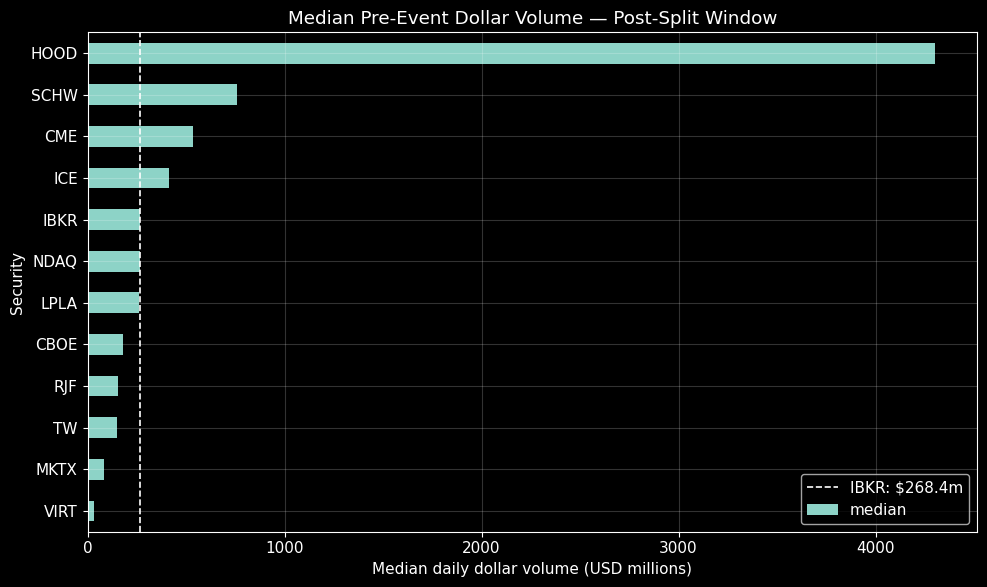

In [46]:
median_liquidity_millions = (
    liquidity_distribution['median'].sort_values() / 1_000_000
)
fig, ax = plt.subplots(figsize=(10, 6))
median_liquidity_millions.plot(kind='barh', ax=ax)
ax.set_title('Median Pre-Event Dollar Volume — Post-Split Window')
ax.set_xlabel('Median daily dollar volume (USD millions)')
ax.set_ylabel('Security')
ax.axvline(
    median_liquidity_millions[TARGET], linestyle='--', linewidth=1.2,
    label=f'IBKR: ${median_liquidity_millions[TARGET]:,.1f}m',
)
ax.legend()
fig.tight_layout()
plt.show()


HOOD is the most liquid name by a wide margin, while VIRT is the least liquid. IBKR sits in the middle of this group at about $268 million per day.


### 9.2 Linear execution cost

The **bid** is the best displayed price at which one can sell, while the **ask** is the best displayed price at which one can buy. Their difference is the full bid–ask spread, for example:

- bid = 99.95, mid = 100.00, ask = 100.05
- full spread $S=100.05-99.95=0.10$, or 10 basis points of the mid
- an aggressive buy pays $Ask-Mid=S/2=5$ bps
- an aggressive sell gives up $Mid-Bid=S/2=5$ bps
- the two sides together cost $S/2+S/2=S$

The exact historical quotes are unavailable, therefore I implement the non-negative Corwin–Schultz high–low estimator. Its intuition is that daily high–low ranges contain both volatility and spread information, comparing one-day and two-day ranges separates the two only approximately. Half of the estimated full spread is charged for each one-way trade. Importantly is not the event-time spread faced by an institution: daily ranges include volatility, and open/close auctions or event-driven liquidity can be materially different. [Published method](https://doi.org/10.1111/j.1540-6261.2012.01729.x)

I also assume that commissions and fees follow a positive lognormal distribution with median 1 bp one-way and a 5–95% interval of 0.25–4 bps. The [public IBKR schedule](https://www.interactivebrokers.com/en/pricing/commissions-stocks.php?re=amer) provides an order-of-magnitude reference.

For security $s$ at execution event $e$, define the one-way proportional rate

$$c_{s,e}=\frac{spread_{s,e}}{2}+commission_{s,e}$$

If $q$ is the signed IBKR target notional and $m_{s,e}$ is that trade's multiplier per dollar of $q$, its linear cost is

$$Cost_{s,e}(q)=c_{s,e}|q||m_{s,e}|$$

Adding every target, hedge, rebalance and exit transaction gives

$$C_{linear}(q)=|q|\sum_{s,e}c_{s,e}|m_{s,e}|=c_{strategy}|q|$$

where $c_{strategy}=\sum_{s,e}c_{s,e}|m_{s,e}|$. This is **not the IBKR spread**, but it is the proportional cost of executing the entire residual strategy per $1 of IBKR target notional. The trade schedule implies approximately $1+1.0468+0.1390+1.1851+1=4.3709$ dollars of gross transactions for each $1 of absolute target notional.


In [47]:
PARTICIPATION_RATE = 0.05  # [Policy choice]

def build_unit_execution_schedule():
    rows = [
        {'stage': 'target_entry', 'ticker': TARGET, 'trade_multiplier': 1.0},
        {'stage': 'target_exit', 'ticker': TARGET, 'trade_multiplier': -1.0},
    ]
    for donor in EXPECTED_EVENT_DONORS:
        w_oc = float(oc_donor_return_exposures[donor])
        w_cc = float(cc_donor_return_exposures[donor])
        rows.extend([
            {'stage': 'hedge_entry_OC', 'ticker': donor,
             'trade_multiplier': -w_oc},
            {'stage': 'hedge_rebalance_OC_to_CC', 'ticker': donor,
             'trade_multiplier': -(w_cc - w_oc)},
            {'stage': 'hedge_exit_CC', 'ticker': donor,
             'trade_multiplier': w_cc},
        ])
    schedule = pd.DataFrame(rows)
    schedule['absolute_trade_multiplier'] = schedule['trade_multiplier'].abs()
    return schedule

def strategy_positions_by_leg(q):
    q = float(q)
    rows = []
    for leg, exposures in [('OC', oc_donor_return_exposures),
                           ('CC', cc_donor_return_exposures)]:
        rows.append({'leg': leg, 'ticker': TARGET, 'position_notional': q})
        rows.extend(
            {'leg': leg, 'ticker': donor,
             'position_notional': -q * float(exposures[donor])}
            for donor in EXPECTED_EVENT_DONORS
        )
    return pd.DataFrame(rows)

unit_execution_schedule = build_unit_execution_schedule()
median_dollar_volume = post_split_dollar_volume.median()
unit_execution_schedule['median_dollar_volume'] = (
    unit_execution_schedule['ticker'].map(median_dollar_volume)
)
active_trades = unit_execution_schedule['absolute_trade_multiplier'].gt(1e-15)
unit_execution_schedule['target_capacity'] = np.where(
    active_trades,
    PARTICIPATION_RATE * unit_execution_schedule['median_dollar_volume']
    / unit_execution_schedule['absolute_trade_multiplier'],
    np.inf,
)
strategy_capacity = float(unit_execution_schedule['target_capacity'].min())
empirical_schedule_capacity = strategy_capacity
capacity_limiting_trade = unit_execution_schedule.loc[
    unit_execution_schedule['target_capacity'].idxmin()
]

turnover_multipliers = pd.Series({
    'target_entry_and_exit': 2.0,
    'donor_initial': oc_donor_return_exposures.abs().sum(),
    'donor_rebalance': (cc_donor_return_exposures - oc_donor_return_exposures).abs().sum(),
    'donor_exit': cc_donor_return_exposures.abs().sum(),
})
turnover_multipliers.loc['total'] = turnover_multipliers.sum()
assert np.isclose(
    turnover_multipliers.loc['total'],
    unit_execution_schedule['absolute_trade_multiplier'].sum(),
)
display(turnover_multipliers.to_frame('multiplier_per_abs_q'))
display(unit_execution_schedule)


,multiplier_per_abs_q
target_entry_and_exit,2.0000
donor_initial,1.0468
donor_rebalance,0.1390
donor_exit,1.1851
total,4.3709


,stage,ticker,trade_multiplier,absolute_trade_multiplier,median_dollar_volume,target_capacity
0,target_entry,IBKR,1.0000,1.0000,"268,391,599.4621","13,419,579.9731"
1,target_exit,IBKR,-1.0000,1.0000,"268,391,599.4621","13,419,579.9731"
2,hedge_entry_OC,SCHW,-0.2028,0.2028,"760,858,259.7023","187,618,006.0574"
3,hedge_rebalance_OC_to_CC,SCHW,0.0004,0.0004,"760,858,259.7023","108,627,482,174.7351"
4,hedge_exit_CC,SCHW,0.2024,0.2024,"760,858,259.7023","187,942,614.6915"
5,hedge_entry_OC,HOOD,-0.0594,0.0594,"4,299,558,590.4568","3,616,571,003.1765"
6,hedge_rebalance_OC_to_CC,HOOD,-0.0015,0.0015,"4,299,558,590.4568","144,770,549,565.4967"
7,hedge_exit_CC,HOOD,0.0609,0.0609,"4,299,558,590.4568","3,528,425,982.4302"
8,hedge_entry_OC,LPLA,-0.1921,0.1921,"263,002,218.1229","68,460,919.2132"
9,hedge_rebalance_OC_to_CC,LPLA,-0.0102,0.0102,"263,002,218.1229","1,294,009,891.6204"


### 9.3 Market impact

Spread and commissions are approximately proportional to order size. Market impact, however, is different: a large order must interact with progressively more limited liquidity, so its total cost grows faster than $|q|$.

Following the literature, I start with the empirical square-root relation for marginal impact:

$$MI(p)=Y\sigma\sqrt{p},\qquad p=Q/V$$

$Q$ is the security-level order notional, $V$ is daily dollar volume, $p$ is participation, $\sigma$ is recent daily volatility, and $Y$ is a dimensionless impact constant. Larger participation, volatility or $Y$ raises impact, evidence supports concave impact, but not a single globally universal $Y$ ([Moro et al.](https://arxiv.org/abs/0908.0202); [Zarinelli et al.](https://arxiv.org/abs/1412.2152)). I assume a lognormal $Y$ with median 1 and a 5–95% interval of 0.5–2.0. Because $MI(p)$ is marginal, I integrate from zero to the completed participation rate:

$$\int_0^pY\sigma\sqrt{u}\,du=\frac{2}{3}Y\sigma p^{3/2}$$

The optimizer uses quadratic cost per dollar of ADV, $\tfrac12\eta p^2$. To make it locally consistent with square-root cost at the policy point $p_0=5\%$, I equate total costs:

$$\frac12\eta p_0^2=\frac23Y\sigma p_0^{3/2}$$

and solve for

$$\eta=\frac43\frac{Y\sigma}{\sqrt{p_0}}$$

This does **not** make square-root and quadratic impact globally identical, but it only matches them near 5% participation, where the investment policy intends the approximation to operate.

### 9.4 Strategy-level impact coefficient

At event $e$, security $s$ trades notional $qm_{s,e}$, its quadratic impact is

$$I_{s,e}=\frac12\frac{\eta_s}{V_s}(qm_{s,e})^2=\frac12q^2\frac{\eta_s}{V_s}m_{s,e}^2$$

Adding every execution event produces

$$I_{strategy}(q)=\frac12q^2\sum_{s,e}\frac{\eta_s}{V_s}m_{s,e}^2=\frac12\kappa_{strategy}q^2$$

where

$$\kappa_{strategy}=\sum_{s,e}\frac{\eta_s}{V_s}m_{s,e}^2$$

$\kappa_{strategy}$ compresses nonlinear impact from the target entry and exit, every donor entry, the OC-to-CC rebalance and every donor exit into one coefficient. Higher liquidity $V_s$ lowers a leg's contribution, while higher $\eta_s$ raises it and a larger $|m_{s,e}|$ matters quadratically because the multiplier is squared. Since $\eta$ is dimensionless and $V$ is in USD, $\kappa$ has units $USD^{-1}$, so $\kappa q^2$ is a dollar cost.

### 9.5 How uncertainty in $\kappa$ is propagated

$\kappa$ is not directly observed since liquidity varies, volatility is estimated, and $Y$ is calibrated. Using a Monte Carlo iteration $b$:

1. resamples common dates to obtain plausible $V_s^{(b)}$ values while preserving cross-security dependence
2. resamples common return dates to estimate $\sigma_s^{(b)}$
3. draws $Y_s^{(b)}$ from its calibrated distribution
4. computes $\eta_s^{(b)}=\tfrac43Y_s^{(b)}\sigma_s^{(b)}/\sqrt{0.05}$
5. computes $\kappa_{strategy}^{(b)}=\sum_{s,e}[\eta_s^{(b)}/V_s^{(b)}]m_{s,e}^2$

Repeating this 4,000 times produces plausible values $\kappa^{(1)},\ldots,\kappa^{(4000)}$.

### 9.6 Borrow

A short residual ($q<0$) shorts IBKR and generally buys donors with positive regression weights, while donors with negative weights are short as well. Borrow must therefore be calculated from the actual sign of every overnight target and hedge position—not from IBKR alone.

I assumed the annual borrow rate lognormal with median 1% and a 5–95% interval of 0.25–4%. Stock-loan availability and fees are dynamic ([IBKR availability](https://www.interactivebrokers.com/en/trading/short-securities-availability.php); [borrow-cost mechanics](https://www.interactivebrokers.com/en/pricing/short-sale-cost.php)), so this is an educational assumption rather than accurate historical evidence. For short notional $N_{short}$ held for $T$ days:

$$C_{borrow}\approx N_{short}b_{annual}\frac{T}{D}$$

where $D$ is the financing day-count basis (360 in the implementation; 365 is another common approximation). At the selected $q^*$, median-rate borrow is only about **$430**, so it is economically small here even though it is not set to zero.


In [48]:
from scipy.optimize import minimize_scalar
from scipy.stats import norm

CALIBRATION_DRAWS = 4_000
CALIBRATION_SEED = 20250909
commission_median = 0.0001  # 1 bp one-way [Assumption]
commission_q05 = 0.000025
commission_q95 = 0.0004
impact_Y_median = 1.0  # [Literature calibration]
impact_Y_q05 = 0.5
impact_Y_q95 = 2.0
borrow_annual_median = 0.01  # [Assumption]
borrow_annual_q05 = 0.0025
borrow_annual_q95 = 0.04

def lognormal_sigma_from_q95(median, q95):
    return np.log(q95 / median) / norm.ppf(0.95)

commission_log_sigma = lognormal_sigma_from_q95(commission_median, commission_q95)
impact_Y_log_sigma = lognormal_sigma_from_q95(impact_Y_median, impact_Y_q95)
borrow_log_sigma = lognormal_sigma_from_q95(borrow_annual_median, borrow_annual_q95)

calibration_tickers = post_split_close.columns.tolist()
recent_cc_log_returns = np.log(post_split_close / post_split_close.shift(1)).dropna()
empirical_daily_sigma = recent_cc_log_returns.std(ddof=1)
calibration_rng = np.random.default_rng(CALIBRATION_SEED)
liquidity_indices = calibration_rng.integers(
    0, len(post_split_dollar_volume), size=(CALIBRATION_DRAWS, len(post_split_dollar_volume))
)
return_indices = calibration_rng.integers(
    0, len(recent_cc_log_returns), size=(CALIBRATION_DRAWS, len(recent_cc_log_returns))
)
spread_indices = calibration_rng.integers(
    0, len(one_way_half_spread_proxy),
    size=(CALIBRATION_DRAWS, len(one_way_half_spread_proxy)),
)
dollar_volume_draws = np.median(
    post_split_dollar_volume[calibration_tickers].to_numpy()[liquidity_indices], axis=1
)
sigma_draws = np.std(
    recent_cc_log_returns[calibration_tickers].to_numpy()[return_indices],
    axis=1, ddof=1,
)
half_spread_draws = np.median(
    one_way_half_spread_proxy[calibration_tickers].to_numpy()[spread_indices], axis=1
)
commission_rate_draws = calibration_rng.lognormal(
    mean=np.log(commission_median), sigma=commission_log_sigma,
    size=CALIBRATION_DRAWS,
)
impact_Y_draws = calibration_rng.lognormal(
    mean=np.log(impact_Y_median), sigma=impact_Y_log_sigma,
    size=(CALIBRATION_DRAWS, len(calibration_tickers)),
)
borrow_annual_rate_draws = calibration_rng.lognormal(
    mean=np.log(borrow_annual_median), sigma=borrow_log_sigma,
    size=CALIBRATION_DRAWS,
)

absolute_multiplier_by_ticker = unit_execution_schedule.groupby('ticker')[
    'absolute_trade_multiplier'
].sum().reindex(calibration_tickers).to_numpy()
squared_multiplier_by_ticker = unit_execution_schedule.assign(
    squared=lambda frame: frame['trade_multiplier'].pow(2)
).groupby('ticker')['squared'].sum().reindex(calibration_tickers).to_numpy()
maximum_multiplier_by_ticker = unit_execution_schedule.groupby('ticker')[
    'absolute_trade_multiplier'
].max().reindex(calibration_tickers).to_numpy()

execution_rate_draws = (
    half_spread_draws @ absolute_multiplier_by_ticker
    + commission_rate_draws * absolute_multiplier_by_ticker.sum()
)
eta_draws = (
    (4 / 3) * impact_Y_draws * sigma_draws / np.sqrt(PARTICIPATION_RATE)
)
kappa_strategy_draws = np.sum(
    eta_draws / dollar_volume_draws * squared_multiplier_by_ticker, axis=1
)
capacity_draws = np.min(
    PARTICIPATION_RATE * dollar_volume_draws / maximum_multiplier_by_ticker, axis=1
)

def overnight_short_multiplier(direction):
    positions = strategy_positions_by_leg(float(direction))
    cc_positions = positions.loc[positions['leg'].eq('CC'), 'position_notional']
    return float((-cc_positions.clip(upper=0)).sum())

short_multiplier_long = overnight_short_multiplier(1)
short_multiplier_short = overnight_short_multiplier(-1)
borrow_rate_long_draws = borrow_annual_rate_draws / 360 * short_multiplier_long
borrow_rate_short_draws = borrow_annual_rate_draws / 360 * short_multiplier_short
c_long_draws = execution_rate_draws + borrow_rate_long_draws
c_short_draws = execution_rate_draws + borrow_rate_short_draws

c_long = float(np.median(c_long_draws))
c_short = float(np.median(c_short_draws))
kappa_strategy = float(np.median(kappa_strategy_draws))
strategy_capacity = min(
    float(np.median(capacity_draws)), empirical_schedule_capacity
)
implementation_calibration_summary = pd.DataFrame({
    'median': [np.median(execution_rate_draws), c_long, c_short, kappa_strategy, strategy_capacity],
    'q05': [np.quantile(execution_rate_draws, 0.05), np.quantile(c_long_draws, 0.05),
             np.quantile(c_short_draws, 0.05), np.quantile(kappa_strategy_draws, 0.05),
             np.quantile(capacity_draws, 0.05)],
    'q95': [np.quantile(execution_rate_draws, 0.95), np.quantile(c_long_draws, 0.95),
             np.quantile(c_short_draws, 0.95), np.quantile(kappa_strategy_draws, 0.95),
             np.quantile(capacity_draws, 0.95)],
    'source_type': ['Empirical proxy + Assumption', 'Proxy/calibration/assumption',
                    'Proxy/calibration/assumption', 'Literature calibration',
                    'Empirical proxy + Policy choice'],
}, index=['execution_rate', 'c_long', 'c_short', 'kappa_strategy', 'capacity'])
display(implementation_calibration_summary)


,median,q05,q95,source_type
execution_rate,0.0080,0.0037,0.0131,Empirical proxy + Assumption
c_long,0.0081,0.0038,0.0132,Proxy/calibration/assumption
c_short,0.0081,0.0038,0.0132,Proxy/calibration/assumption
kappa_strategy,0.0000,0.0000,0.0000,Literature calibration
capacity,"13,419,579.9731","12,922,439.7816","15,483,445.6049",Empirical proxy + Policy choice


The following chart shows how proportional execution cost and nonlinear impact behave as the target notional grows. Borrow is excluded from this picture because it is direction-specific and very small.


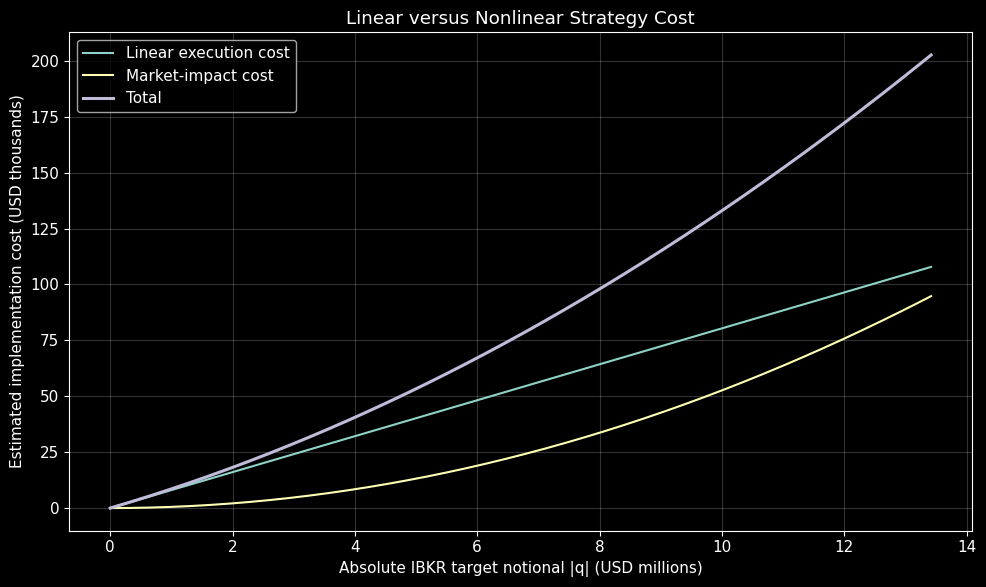

In [49]:
cost_grid = np.linspace(0.0, strategy_capacity, 250)
central_execution_rate = float(np.median(execution_rate_draws))
linear_execution_cost = central_execution_rate * cost_grid
market_impact_cost = 0.5 * kappa_strategy * cost_grid ** 2
total_implementation_cost = linear_execution_cost + market_impact_cost
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cost_grid / 1_000_000, linear_execution_cost / 1_000, label='Linear execution cost')
ax.plot(cost_grid / 1_000_000, market_impact_cost / 1_000, label='Market-impact cost')
ax.plot(cost_grid / 1_000_000, total_implementation_cost / 1_000, linewidth=2.2, label='Total')
ax.set_title('Linear versus Nonlinear Strategy Cost')
ax.set_xlabel('Absolute IBKR target notional |q| (USD millions)')
ax.set_ylabel('Estimated implementation cost (USD thousands)')
ax.legend()
fig.tight_layout()
plt.show()


Linear cost rises at a constant slope, whereas impact bends upward with size. Near the $13.42 million capacity point, the two components are of similar order, so ignoring either would materially understate implementation cost.


 The histogram shows the simulated $\kappa$ values directly, illustrateing how uncertain is the strategy-level impact coefficient.


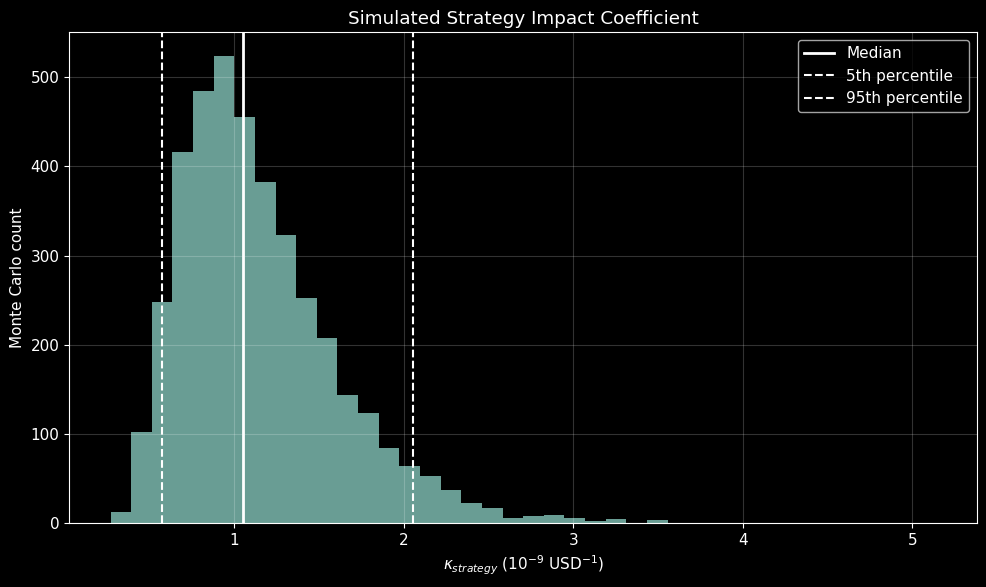

In [50]:
kappa_q05, kappa_median, kappa_q95 = np.quantile(
    kappa_strategy_draws, [0.05, 0.50, 0.95]
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(kappa_strategy_draws * 1e9, bins=40, alpha=0.75)
ax.axvline(kappa_median * 1e9, linewidth=2, label='Median')
ax.axvline(kappa_q05 * 1e9, linestyle='--', label='5th percentile')
ax.axvline(kappa_q95 * 1e9, linestyle='--', label='95th percentile')
ax.set_title('Simulated Strategy Impact Coefficient')
ax.set_xlabel(r'$\kappa_{strategy}$ ($10^{-9}$ USD$^{-1}$)')
ax.set_ylabel('Monte Carlo count')
ax.legend()
fig.tight_layout()
plt.show()


The distribution is positive and right-skewed, which is consistent with uncertain positive liquidity costs rather than symmetric estimation noise. Its width is a reminder that the median $\kappa$ is a central calibration, not a precisely observed market constant.


### 9.7 Multi-leg capacity

As a policy choice and assumption, no individual execution may exceed $\phi=5\%$ of that security's estimated daily dollar volume. A relatively low participation rate also keeps the local impact approximation closer to its calibration point. For security $s$ and event $e$, required notional is $|q||m_{s,e}|$ and allowed notional is $\phi V_s$, thus:

$$|q||m_{s,e}|\leq\phi V_s\quad\Longrightarrow\quad |q|\leq q_{capacity,s,e}=\frac{\phi V_s}{|m_{s,e}|}$$

Every transaction must pass, so strategy capacity is the weakest link:

$$q_{capacity}=\min_{s,e}q_{capacity,s,e}$$

For intuition, IBKR dollar volume of about $268 million permits a 5% target trade of about $13.4 million when its multiplier is 1. A donor with $100 million of dollar volume and a 0.20 multiplier permits a $5 million donor trade, corresponding to $5m/0.20=$ **$25 million** of target notional. IBKR is more restrictive in that example, but the notebook does not assume this in advance. It checks target entry, every initial hedge, every rebalance, every donor close and target exit separately.

The following chart illustrates which transactions form the strategy's capacity bottleneck. A logarithmic axis keeps both the smallest and very large implied capacities readable, while the highlighted bars attain the minimum.


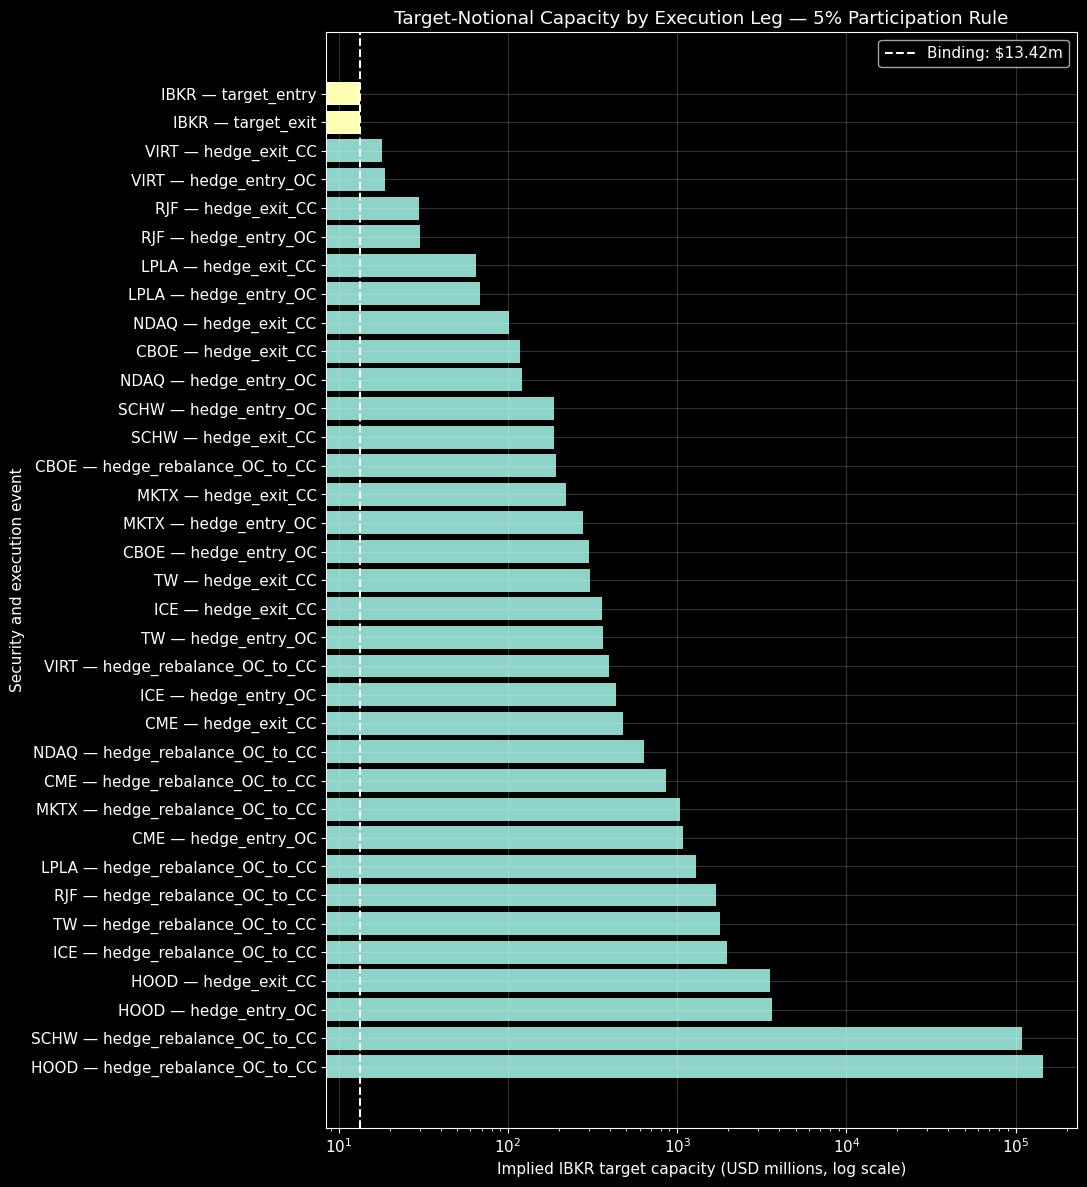

In [51]:
capacity_chart = unit_execution_schedule.copy()
capacity_chart['label'] = (
    capacity_chart['ticker'] + ' — ' + capacity_chart['stage']
)
capacity_chart['capacity_millions'] = capacity_chart['target_capacity'] / 1_000_000
capacity_chart = capacity_chart.sort_values('capacity_millions', ascending=False)
binding_capacity = capacity_chart['capacity_millions'].min()
binding_mask = np.isclose(capacity_chart['capacity_millions'], binding_capacity)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
bar_colors = [default_colors[1] if is_binding else default_colors[0] for is_binding in binding_mask]
fig, ax = plt.subplots(figsize=(11, 12))
ax.barh(capacity_chart['label'], capacity_chart['capacity_millions'], color=bar_colors)
ax.set_xscale('log')
ax.axvline(binding_capacity, linestyle='--', linewidth=1.5, label=f'Binding: ${binding_capacity:,.2f}m')
ax.set_title('Target-Notional Capacity by Execution Leg — 5% Participation Rule')
ax.set_xlabel('Implied IBKR target capacity (USD millions, log scale)')
ax.set_ylabel('Security and execution event')
ax.legend()
fig.tight_layout()
plt.show()


The binding observations are IBKR target entry and target exit, each near $13.42 million.

## 10. Investor Policy

If liquidity, spread, volatility, impact and borrow attempt, imperfectly, to describe market conditions, the quantities below do something different: they encode the mandate under which the investor is willing to hold the residual trade. They are policy choice inputs, not estimates and not universally correct values.

- $W=\$50$ million is fund wealth, it determines the scale over which strategy P&L and utility are evaluated
- $\rho=4$ is CRRA risk aversion, it controls how strongly uncertain P&L is penalized relative to expected P&L. It is a preference, not a statistically estimated coefficient
- $L=\$500{,}000=1\%$ of wealth is the maximum modelled lower-tail loss budget
- $\alpha=5\%$ defines Expected Shortfall: the average P&L among the worst 5% of modelled outcomes. Averaging a tail is more stable and informative here than focusing on one single worst simulated draw
- $\phi=5\%$ limits every required execution to 5% of that security's estimated daily dollar volume

In [52]:
PORTFOLIO_WEALTH = 50_000_000.0  # [Policy choice]
CRRA_RISK_AVERSION = 4.0  # [Policy choice]
TAIL_LOSS_BUDGET = 500_000.0  # [Policy choice]
ES_TAIL_PROBABILITY = 0.05  # [Policy choice]
assert np.isclose(TAIL_LOSS_BUDGET / PORTFOLIO_WEALTH, 0.01)
assert np.isclose(PARTICIPATION_RATE, 0.05)
investor_policy = pd.DataFrame([
    {'parameter': 'W', 'value': PORTFOLIO_WEALTH, 'meaning': 'fund scale'},
    {'parameter': 'rho', 'value': CRRA_RISK_AVERSION, 'meaning': 'CRRA risk aversion'},
    {'parameter': 'L', 'value': TAIL_LOSS_BUDGET, 'meaning': 'maximum ES loss'},
    {'parameter': 'alpha', 'value': ES_TAIL_PROBABILITY, 'meaning': 'worst-tail probability'},
    {'parameter': 'phi', 'value': PARTICIPATION_RATE, 'meaning': 'per-trade DV participation'},
])
investor_policy['source_type'] = 'Policy choice'
display(investor_policy)


,parameter,value,meaning,source_type
0,W,"50,000,000.0000",fund scale,Policy choice
1,rho,4.0000,CRRA risk aversion,Policy choice
2,L,"500,000.0000",maximum ES loss,Policy choice
3,alpha,0.0500,worst-tail probability,Policy choice
4,phi,0.0500,per-trade DV participation,Policy choice


In [53]:
oc_simple_returns = np.expm1(primary_leg_returns['OC'])
cc_simple_returns = np.expm1(primary_leg_returns['CC'])
self_financing_simple_approximation = float(
    oc_simple_returns[TARGET]
    - oc_donor_return_exposures @ oc_simple_returns[EXPECTED_EVENT_DONORS]
    + cc_simple_returns[TARGET]
    - cc_donor_return_exposures @ cc_simple_returns[EXPECTED_EVENT_DONORS]
)
return_space_discrepancy = float(
    self_financing_simple_approximation - primary_tradeable_residual_simple
)
display(pd.Series({
    'log_return_space_converted_simple': primary_tradeable_residual_simple,
    'fixed_notional_simple_PnL_approximation': self_financing_simple_approximation,
    'simple_return_discrepancy': return_space_discrepancy,
}, name='return_space_limit').to_frame('value'))


,value
log_return_space_converted_simple,-0.0512
fixed_notional_simple_PnL_approximation,-0.0522
simple_return_discrepancy,-0.0011


## 11. Optimal Position

So, given the residual-return distribution, execution costs, market impact, risk aversion, tail-loss budget and capacity, what signed IBKR target position should the investor choose?

First of all, the sign convention is important: $q>0$ is long the IBKR residual, $q<0$ is short it, and $q=0$ means no trade. For residual simple return $R$, modelled dollar P&L is

$$X(q)=qR-C_{linear}(q)-C_{borrow}(q)-\frac12\kappa_{strategy}q^2$$

$qR$ is gross residual P&L, $C_{linear}$ covers spread and commissions across all executions, $C_{borrow}$ applies to actual overnight shorts and the final term is nonlinear impact. Costs may differ by direction because long and short residual portfolios have different borrowed positions.

### 11.1 Direction and magnitude

I consider $q=ds$, where $d\in\{-1,+1\}$ selects short or long and $s\geq0$ is absolute size. This operation lets the research design solve each direction as a non-negative one-dimensional problem and then compare both with no trade. Starting from the second-order CRRA certainty-equivalent approximation

$$CE\approx E[X]-\frac{\rho}{2W}Var(X)$$

Let $\mu=E[R]$, $\sigma_R^2=Var(R)$ and let $c_d$ be the direction-specific strategy linear-cost rate, including borrow. For size $s$,

$$E[X]=s(d\mu-c_d)-\frac12\kappa_{strategy}s^2$$

Only the random return term contributes variance in this approximation. Because $d^2=1$,

$$Var(dsR)=d^2s^2Var(R)=s^2\sigma_R^2$$

Substitution gives the direction-specific objective

$$
J_d(s)
=
s(d\mu-c_d)
-
\frac{1}{2}
\left(
\kappa_{\mathrm{strategy}}
+
\frac{\rho}{W}\sigma_R^2
\right)s^2
$$

Differentiate with respect to size:

$$
\frac{\mathrm{d}J_d}{\mathrm{d}s}
=
d\mu-c_d
-
\left(
\kappa_{\mathrm{strategy}}
+
\frac{\rho}{W}\sigma_R^2
\right)s
$$

Setting the derivative to zero gives the unconstrained risk-preferred size

$$
s_{\mathrm{risk},d}
=
\frac{
\max\left(d\mu-c_d,\,0\right)
}{
\kappa_{\mathrm{strategy}}
+
\frac{\rho}{W}\sigma_R^2
}
$$ 

The numerator is expected directional return after linear cost: if it is negative, the maximum operator creates an endogenous no-trade outcome, while the denominator combines nonlinear impact with the investor's penalty for return variance. Increasing $\kappa$, $\rho$ or $\sigma_R^2$ reduces preferred size, while greater wealth weakens the variance penalty.

### 11.2 Expected-Shortfall limit

For return draw $i$, I DEFINE  unit directional net return $Z_i=dR_i-c_d$, The lower-tail $ES_\alpha(Z)$ is the average of the worst $\alpha$ fraction of these draws. At size $s$, tail P&L is

$$sES_\alpha(Z)-\frac12\kappa s^2$$

Requiring this to remain above $-L$ gives

$$
\frac{1}{2}\kappa s^2
-
\operatorname{ES}_{\alpha}(Z)s
-
L
\leq 0
$$

The positive root is the largest size permitted by the tail-loss budget:

$$
s_{\mathrm{loss},d}
=
\frac{
\operatorname{ES}_{\alpha}(Z)
+
\sqrt{
\operatorname{ES}_{\alpha}(Z)^2
+
2\kappa L
}
}{
\kappa
}
$$

Finally, each directional candidate is

$$
s_d^{*}
=
\min\left\{
s_{\mathrm{risk},d},
\,s_{\mathrm{loss},d},
\,s_{\mathrm{capacity}}
\right\},
\qquad
q_d^{*}
=
d\,s_d^{*}
$$

I evaluate long, short and zero, then choose the highest certainty equivalent. The result is approximately **$q^*=-\$13.42 million**, or **209,202 IBKR shares short**, with the dynamically rebalanced donor hedge. Expected net P&L is about **$539,839**, P&L volatility about **$249,013**, and 5% Expected Shortfall about **−$65,767**. ES is far inside the −$500,000 policy limit, so multi-leg capacity is binding.

In [54]:
strategy_return_draws = primary_tradeable_residual_draws_simple.to_numpy(dtype=float)
strategy_return_mean = float(strategy_return_draws.mean())
strategy_return_variance = float(strategy_return_draws.var(ddof=1))
strategy_return_volatility = float(strategy_return_draws.std(ddof=1))

def lower_tail_expected_shortfall(values, alpha):
    values = np.sort(np.asarray(values, dtype=float))
    tail_count = max(1, int(np.ceil(alpha * len(values))))
    return float(values[:tail_count].mean())

def loss_budget_position_limit(direction, returns, cost_rate, kappa):
    unit_tail = lower_tail_expected_shortfall(
        direction * np.asarray(returns) - cost_rate, ES_TAIL_PROBABILITY
    )
    if kappa > 0:
        limit = (unit_tail + np.sqrt(
            unit_tail ** 2 + 2 * kappa * TAIL_LOSS_BUDGET
        )) / kappa
    elif unit_tail < 0:
        limit = TAIL_LOSS_BUDGET / (-unit_tail)
    else:
        limit = np.inf
    return float(max(limit, 0)), unit_tail

def evaluate_direction(direction, returns, cost_rate, kappa, capacity):
    returns = np.asarray(returns, dtype=float)
    mean_return = float(returns.mean())
    return_variance = float(returns.var(ddof=1))
    denominator = kappa + CRRA_RISK_AVERSION / PORTFOLIO_WEALTH * return_variance
    risk_limit = max(direction * mean_return - cost_rate, 0) / denominator
    loss_limit, unit_tail = loss_budget_position_limit(
        direction, returns, cost_rate, kappa
    )
    constraints = {
        'risk_optimum': float(risk_limit),
        'ES_loss_budget': float(loss_limit),
        'multi_leg_capacity': float(capacity),
    }
    size = min(constraints.values())
    binding_constraint = min(constraints, key=constraints.get)
    certainty_equivalent = (
        size * (direction * mean_return - cost_rate)
        - 0.5 * denominator * size ** 2
    )
    pnl_draws = (
        size * (direction * returns - cost_rate)
        - 0.5 * kappa * size ** 2
    )
    return {
        'direction': int(direction), 'size': float(size),
        'q': float(direction * size),
        'cost_rate': float(cost_rate),
        's_risk': float(risk_limit), 's_loss': float(loss_limit),
        's_capacity': float(capacity),
        'binding_constraint': binding_constraint,
        'certainty_equivalent': float(certainty_equivalent),
        'expected_pnl': float(pnl_draws.mean()),
        'pnl_volatility': float(pnl_draws.std(ddof=1)),
        'ES_5pct': lower_tail_expected_shortfall(pnl_draws, ES_TAIL_PROBABILITY),
        'unit_tail_return': float(unit_tail),
        'pnl_draws': pnl_draws,
    }


In [55]:
long_candidate = evaluate_direction(
    1, strategy_return_draws, c_long, kappa_strategy, strategy_capacity
)
short_candidate = evaluate_direction(
    -1, strategy_return_draws, c_short, kappa_strategy, strategy_capacity
)
no_trade_candidate = {
    'direction': 0, 'size': 0.0, 'q': 0.0, 'cost_rate': 0.0,
    's_risk': 0.0, 's_loss': np.inf, 's_capacity': strategy_capacity,
    'binding_constraint': 'no_trade', 'certainty_equivalent': 0.0,
    'expected_pnl': 0.0, 'pnl_volatility': 0.0, 'ES_5pct': 0.0,
    'unit_tail_return': 0.0, 'pnl_draws': np.zeros_like(strategy_return_draws),
}
approximate_candidates = [long_candidate, short_candidate, no_trade_candidate]
approximate_optimum = max(
    approximate_candidates, key=lambda candidate: candidate['certainty_equivalent']
)
q_star_approx = float(approximate_optimum['q'])

candidate_columns = [
    'direction', 'q', 's_risk', 's_loss', 's_capacity',
    'binding_constraint', 'certainty_equivalent', 'expected_pnl',
    'pnl_volatility', 'ES_5pct',
]
approximate_candidate_summary = pd.DataFrame([
    {column: candidate[column] for column in candidate_columns}
    for candidate in approximate_candidates
]).set_index('direction')

capacity_check_by_trade = unit_execution_schedule.copy()
capacity_check_by_trade['trade_notional'] = (
    abs(q_star_approx) * capacity_check_by_trade['absolute_trade_multiplier']
)
capacity_check_by_trade['participation_limit'] = (
    PARTICIPATION_RATE * capacity_check_by_trade['median_dollar_volume']
)
capacity_check_by_trade['participation_rate'] = (
    capacity_check_by_trade['trade_notional']
    / capacity_check_by_trade['median_dollar_volume']
)
capacity_check_by_trade['signed_trade_notional'] = (
    q_star_approx * capacity_check_by_trade['trade_multiplier']
)
capacity_check_by_trade['passes'] = (
    capacity_check_by_trade['trade_notional']
    <= capacity_check_by_trade['participation_limit'] + 1e-8
)
assert capacity_check_by_trade['passes'].all()
assert approximate_optimum['ES_5pct'] >= -TAIL_LOSS_BUDGET - 1e-6

target_entry_price = float(entry_open[TARGET])
target_shares_approx = q_star_approx / target_entry_price
optimal_leg_notionals = strategy_positions_by_leg(q_star_approx)
optimal_leg_notionals['position_side'] = np.where(
    optimal_leg_notionals['position_notional'] >= 0, 'long', 'short'
)
selected_short_multiplier = (
    short_multiplier_long if q_star_approx >= 0 else short_multiplier_short
)
borrow_dollar_cost_approx = (
    abs(q_star_approx) * borrow_annual_median / 360 * selected_short_multiplier
)

display(approximate_candidate_summary)
display(pd.Series({
    'q_star_approx': q_star_approx,
    'target_entry_price': target_entry_price,
    'target_shares': target_shares_approx,
    'borrow_cost_at_median_rate': borrow_dollar_cost_approx,
    'binding_constraint': approximate_optimum['binding_constraint'],
}, name='approximate_optimum').to_frame('value'))
display(capacity_check_by_trade)
display(optimal_leg_notionals)


,q,s_risk,s_loss,s_capacity,binding_constraint,certainty_equivalent,expected_pnl,pnl_volatility,ES_5pct
direction,,,,,,,,,
1,0.0000,0.0000,"4,718,714.6680","13,419,579.9731",risk_optimum,-0.0000,0.0000,0.0000,0.0000
-1,"-13,419,579.9731","43,786,010.0545","32,946,070.4814","13,419,579.9731",multi_leg_capacity,"537,358.9162","539,839.2187","249,013.1780","-65,766.6162"
0,0.0000,0.0000,inf,"13,419,579.9731",no_trade,0.0000,0.0000,0.0000,0.0000


,value
q_star_approx,"-13,419,579.9731"
target_entry_price,64.1464
target_shares,"-209,202.3413"
borrow_cost_at_median_rate,429.8846
binding_constraint,multi_leg_capacity


,stage,ticker,trade_multiplier,absolute_trade_multiplier,median_dollar_volume,target_capacity,trade_notional,participation_limit,participation_rate,signed_trade_notional,passes
0,target_entry,IBKR,1.0000,1.0000,"268,391,599.4621","13,419,579.9731","13,419,579.9731","13,419,579.9731",0.0500,"-13,419,579.9731",True
1,target_exit,IBKR,-1.0000,1.0000,"268,391,599.4621","13,419,579.9731","13,419,579.9731","13,419,579.9731",0.0500,"13,419,579.9731",True
2,hedge_entry_OC,SCHW,-0.2028,0.2028,"760,858,259.7023","187,618,006.0574","2,721,060.3286","38,042,912.9851",0.0036,"2,721,060.3286",True
3,hedge_rebalance_OC_to_CC,SCHW,0.0004,0.0004,"760,858,259.7023","108,627,482,174.7351","4,699.7307","38,042,912.9851",0.0000,"-4,699.7307",True
4,hedge_exit_CC,SCHW,0.2024,0.2024,"760,858,259.7023","187,942,614.6915","2,716,360.5979","38,042,912.9851",0.0036,"-2,716,360.5979",True
5,hedge_entry_OC,HOOD,-0.0594,0.0594,"4,299,558,590.4568","3,616,571,003.1765","797,693.0399","214,977,929.5228",0.0002,"797,693.0399",True
6,hedge_rebalance_OC_to_CC,HOOD,-0.0015,0.0015,"4,299,558,590.4568","144,770,549,565.4967","19,927.4889","214,977,929.5228",0.0000,"19,927.4889",True
7,hedge_exit_CC,HOOD,0.0609,0.0609,"4,299,558,590.4568","3,528,425,982.4302","817,620.5288","214,977,929.5228",0.0002,"-817,620.5288",True
8,hedge_entry_OC,LPLA,-0.1921,0.1921,"263,002,218.1229","68,460,919.2132","2,577,659.8823","13,150,110.9061",0.0098,"2,577,659.8823",True
9,hedge_rebalance_OC_to_CC,LPLA,-0.0102,0.0102,"263,002,218.1229","1,294,009,891.6204","136,373.7373","13,150,110.9061",0.0005,"136,373.7373",True


,leg,ticker,position_notional,position_side
0,OC,IBKR,"-13,419,579.9731",short
1,OC,SCHW,"2,721,060.3286",long
2,OC,HOOD,"797,693.0399",long
3,OC,LPLA,"2,577,659.8823",long
4,OC,RJF,"3,412,391.7878",long
5,OC,CME,"-334,325.9525",short
6,OC,CBOE,"-408,222.4802",short
7,OC,NDAQ,"1,478,642.7015",long
8,OC,ICE,"633,572.6054",long
9,OC,MKTX,"-205,604.2941",short


The following chart shows why the approximation prefers a short position and what is preventing it from moving to the unconstrained risk optimum


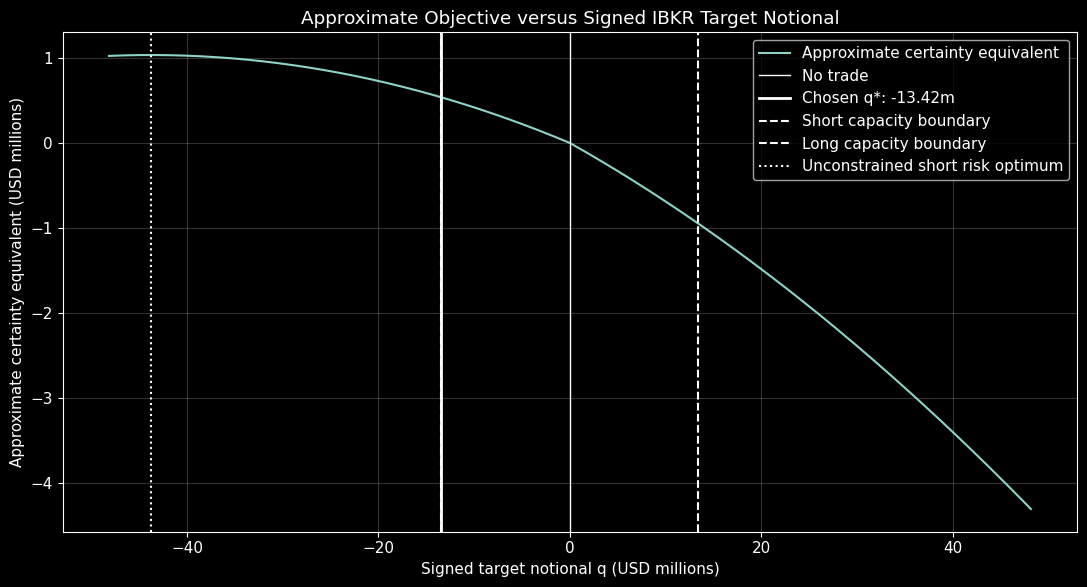

In [56]:
objective_plot_bound = 1.10 * max(
    short_candidate['s_risk'], long_candidate['s_risk'], strategy_capacity
)
objective_q_grid = np.linspace(-objective_plot_bound, objective_plot_bound, 600)
objective_size = np.abs(objective_q_grid)
objective_direction = np.sign(objective_q_grid)
objective_cost_rate = np.where(objective_q_grid < 0, c_short, c_long)
objective_denominator = (
    kappa_strategy
    + CRRA_RISK_AVERSION / PORTFOLIO_WEALTH * strategy_return_variance
)
approximate_objective_curve = (
    objective_size * (objective_direction * strategy_return_mean - objective_cost_rate)
    - 0.5 * objective_denominator * objective_size ** 2
)
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(objective_q_grid / 1_000_000, approximate_objective_curve / 1_000_000,
        label='Approximate certainty equivalent')
ax.axvline(0, linewidth=1, label='No trade')
ax.axvline(q_star_approx / 1_000_000, linewidth=2, label=f'Chosen q*: {q_star_approx/1e6:.2f}m')
ax.axvline(-strategy_capacity / 1_000_000, linestyle='--', label='Short capacity boundary')
ax.axvline(strategy_capacity / 1_000_000, linestyle='--', label='Long capacity boundary')
ax.axvline(-short_candidate['s_risk'] / 1_000_000,
           linestyle=':', linewidth=1.5, label='Unconstrained short risk optimum')
ax.set_title('Approximate Objective versus Signed IBKR Target Notional')
ax.set_xlabel('Signed target notional q (USD millions)')
ax.set_ylabel('Approximate certainty equivalent (USD millions)')
ax.legend()
fig.tight_layout()
plt.show()


The positive-$q$ side never becomes attractive because the event residual mean is negative after costs. On the short side the objective is still rising at the feasible boundary; the unconstrained risk optimum lies much farther left, so it is capacity, and not lack of expected benefit, that is stopping the implemented position.


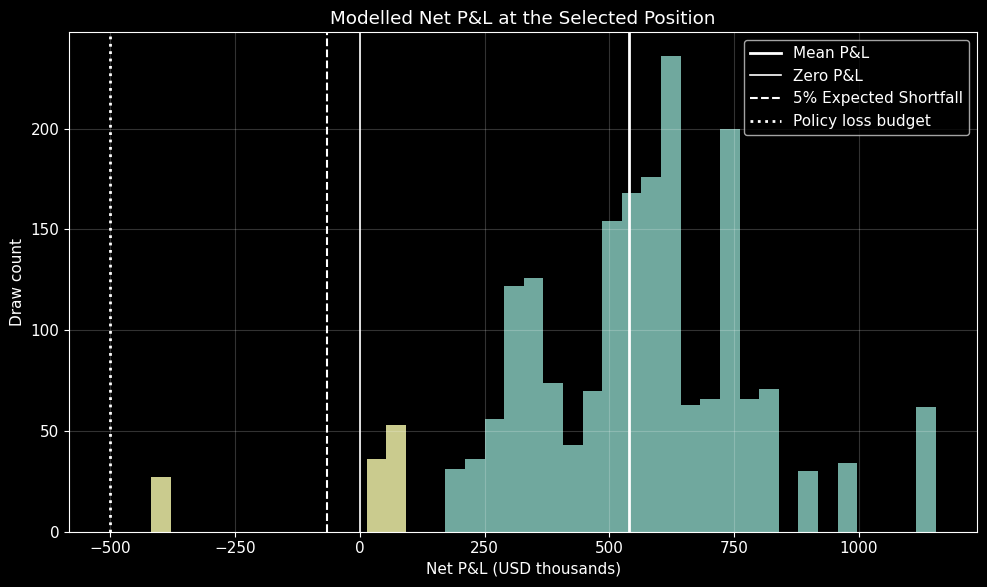

In [57]:
optimal_pnl_draws = approximate_optimum['pnl_draws']
pnl_tail_threshold = float(np.quantile(optimal_pnl_draws, ES_TAIL_PROBABILITY))
fig, ax = plt.subplots(figsize=(10, 6))
counts, bins, patches = ax.hist(optimal_pnl_draws / 1_000, bins=40, alpha=0.8)
chart_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for left_edge, patch in zip(bins[:-1], patches):
    if left_edge * 1_000 <= pnl_tail_threshold:
        patch.set_facecolor(chart_colors[1])
ax.axvline(approximate_optimum['expected_pnl'] / 1_000, linewidth=2, label='Mean P&L')
ax.axvline(0, linewidth=1.2, label='Zero P&L')
ax.axvline(approximate_optimum['ES_5pct'] / 1_000, linestyle='--', label='5% Expected Shortfall')
ax.axvline(-TAIL_LOSS_BUDGET / 1_000, linestyle=':', linewidth=2, label='Policy loss budget')
ax.set_title('Modelled Net P&L at the Selected Position')
ax.set_xlabel('Net P&L (USD thousands)')
ax.set_ylabel('Draw count')
ax.legend()
fig.tight_layout()
plt.show()


Most modelled outcomes are profitable after the calibrated costs, although a lower tail remains. The average of the worst 5% is about −$65.8 thousand, well above the −$500 thousand policy floor and this confirms why Expected Shortfall is not the binding constraint.


## 12. Uncertainty in the Optimal Trade

Of course, the selected position changes when the uncertain empirical and calibrated inputs change, but by how much? The point estimate $q^*=-\$13.42$ million is not known with precision. The optimizer can be written as:

$$q^*=g(\theta)$$

where $\theta$ contains residual-return support, liquidity, spreads, commissions, $Y$ and borrow rates, while investor-policy inputs $W,\rho,L,\alpha$ and $\phi$ remain fixed because they are choices, not uncertain market estimates.

One uncertainty iteration does the following:

1. resample the 62 historical two-session residual/event-support blocks
2. use a common-date resample of pre-event liquidity, preserving cross-security dependence
3. use the corresponding spread and commission calibration draw
4. draw the impact constant $Y$ and recompute each $\eta_s$
5. draw borrow and recompute $c_{long}$ and $c_{short}$ from actual short holdings
6. recompute $\kappa_{strategy}$ and every multi-leg capacity limit
7. solve long, short and no trade again
8. store $q^*$ and the binding constraint

This is repeated $B=1{,}000$ times, however, the 2,000 event draws do **not** represent 2,000 independent observations, but they are generated from only 62 overlapping historical blocks. Even those blocks are not fully independent because adjacent two-session windows overlap. The output is a conditional sensitivity distribution and not a classical confidence interval.

The resulting median is **−$13.420 million**, with a 5–95% interval of **−$15.763 million to −$12.797 million**. All iterations choose the short direction, capacity binds in **99.1%**, the unconstrained risk optimum in **0.5%**, and Expected Shortfall in **0.4%**. Because capacity almost always binds, the apparently narrow $q^*$ interval mainly describes uncertainty in feasible execution capacity—not precise knowledge of the unconstrained economic optimum.


In [58]:
historical_error_blocks = event_handoff_model_audit.loc[
    event_handoff_model_audit['record_type'].eq('primary_tradeable_error_block')
].sort_values('block_id').copy()
assert len(historical_error_blocks) == 62
residual_support_log = (
    source_primary_abnormal_log
    - historical_error_blocks['block_error_log_return'].to_numpy(dtype=float)
    + primary_intercept_sum
)
residual_support_simple = np.expm1(residual_support_log)
assert len(np.unique(residual_support_simple)) == 62
assert np.isin(
    np.round(primary_tradeable_residual_draws_simple.to_numpy(), 14),
    np.round(residual_support_simple, 14),
).all()

OPTIMIZER_BOOTSTRAP_DRAWS = 1_000
OPTIMIZER_BOOTSTRAP_SEED = 20250910
optimizer_rng = np.random.default_rng(OPTIMIZER_BOOTSTRAP_SEED)
optimizer_rows = []
for batch_id in range(OPTIMIZER_BOOTSTRAP_DRAWS):
    sampled_returns = optimizer_rng.choice(
        residual_support_simple, size=len(residual_support_simple), replace=True
    )
    calibration_id = int(optimizer_rng.integers(0, CALIBRATION_DRAWS))
    batch_candidates = [
        evaluate_direction(
            1, sampled_returns, c_long_draws[calibration_id],
            kappa_strategy_draws[calibration_id], capacity_draws[calibration_id],
        ),
        evaluate_direction(
            -1, sampled_returns, c_short_draws[calibration_id],
            kappa_strategy_draws[calibration_id], capacity_draws[calibration_id],
        ),
        no_trade_candidate,
    ]
    selected = max(
        batch_candidates, key=lambda candidate: candidate['certainty_equivalent']
    )
    optimizer_rows.append({
        'batch_id': batch_id, 'calibration_draw_id': calibration_id,
        'q_star': selected['q'],
        'binding_constraint': selected['binding_constraint'],
        'expected_pnl': selected['expected_pnl'],
        'ES_5pct': selected['ES_5pct'],
    })

optimizer_uncertainty_draws = pd.DataFrame(optimizer_rows)
q_uncertainty = optimizer_uncertainty_draws['q_star']
q_zero = np.isclose(q_uncertainty, 0.0, atol=1e-6)
q_uncertainty_summary = pd.Series({
    'median_q_star': q_uncertainty.median(),
    'q05_q_star': q_uncertainty.quantile(0.05),
    'q95_q_star': q_uncertainty.quantile(0.95),
    'probability_q_negative': (q_uncertainty < -1e-6).mean(),
    'probability_q_zero': q_zero.mean(),
    'probability_q_positive': (q_uncertainty > 1e-6).mean(),
}, name='optimal_position_uncertainty')
binding_frequencies = optimizer_uncertainty_draws['binding_constraint'].value_counts(
    normalize=True
).rename('frequency')
assert np.isclose(
    q_uncertainty_summary[['probability_q_negative', 'probability_q_zero',
                           'probability_q_positive']].sum(), 1.0
)
display(q_uncertainty_summary.to_frame('value'))
display(binding_frequencies.to_frame())


,value
median_q_star,"-13,419,579.9731"
q05_q_star,"-15,763,321.0089"
q95_q_star,"-12,796,954.8354"
probability_q_negative,1.0000
probability_q_zero,0.0000
probability_q_positive,0.0000


,frequency
binding_constraint,
multi_leg_capacity,0.9910
risk_optimum,0.0050
ES_loss_budget,0.0040


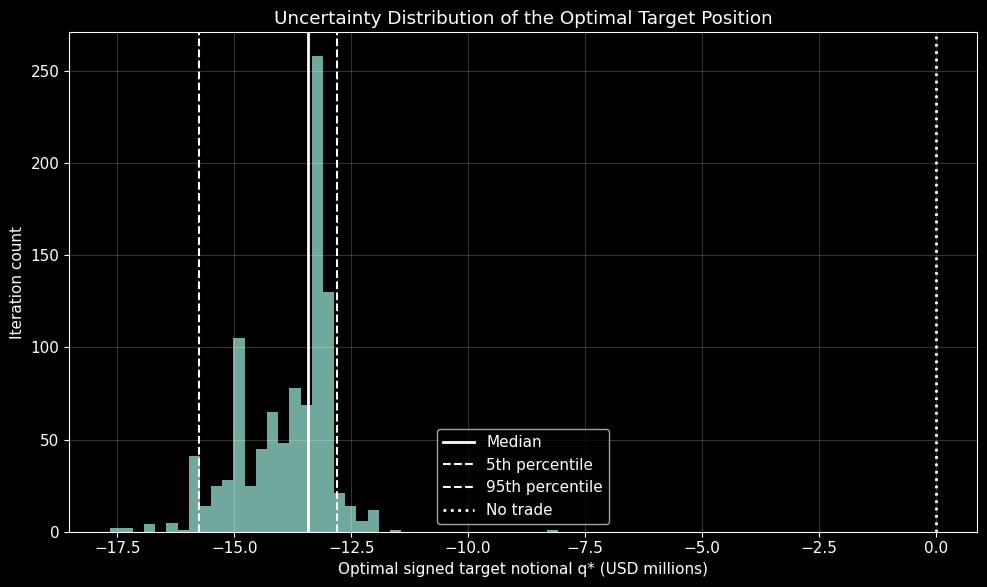

In [59]:
qstar_q05, qstar_median, qstar_q95 = np.quantile(q_uncertainty, [0.05, 0.50, 0.95])
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(q_uncertainty / 1_000_000, bins=40, alpha=0.8)
ax.axvline(qstar_median / 1_000_000, linewidth=2, label='Median')
ax.axvline(qstar_q05 / 1_000_000, linestyle='--', label='5th percentile')
ax.axvline(qstar_q95 / 1_000_000, linestyle='--', label='95th percentile')
ax.axvline(0, linestyle=':', linewidth=2, label='No trade')
ax.set_title('Uncertainty Distribution of the Optimal Target Position')
ax.set_xlabel('Optimal signed target notional q* (USD millions)')
ax.set_ylabel('Iteration count')
ax.legend()
fig.tight_layout()
plt.show()


Every simulated optimum is negative, so direction is stable within this conditional exercise, anyways, concentration near −$13 million should not be mistaken for precise alpha sizing and the next chart shows that these draws are mostly pinned to sampled capacity.


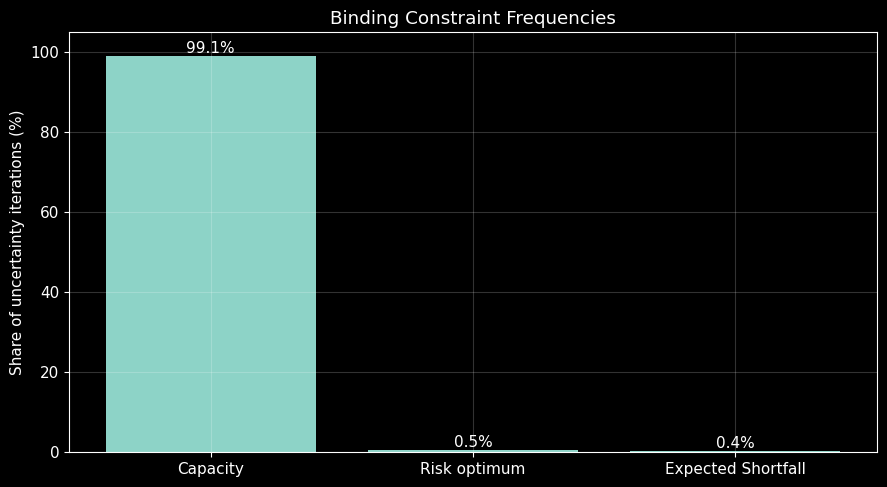

In [60]:
binding_plot = (
    binding_frequencies.reindex(
        ['multi_leg_capacity', 'risk_optimum', 'ES_loss_budget'], fill_value=0
    ) * 100
)
binding_plot.index = ['Capacity', 'Risk optimum', 'Expected Shortfall']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(binding_plot.index, binding_plot.values)
ax.set_title('Binding Constraint Frequencies')
ax.set_ylabel('Share of uncertainty iterations (%)')
ax.set_ylim(0, 105)
ax.bar_label(bars, labels=[f'{value:.1f}%' for value in binding_plot.values])
fig.tight_layout()
plt.show()


Capacity determines the answer in 99.1% of iterations. Risk preference and Expected Shortfall rarely bind, so the central uncertainty is how much of the multi-leg strategy can be executed under the 5% rule and not whether the model prefers a short residual.


## 13. Conclusion

This research connects four different layers:

1. **Event-study result** The PCR models measure a primary-tradeable abnormal event return of approximately **−5.24%**
2. **Tradable residual** Restoring the non-tradable regression intercept produces an approximate tradable residual of **−5.12%**
3. **Trade design** Under the assumption of $50 million mandate, the optimizer reverses that residual: about **$13.42 million short IBKR**, approximately **209,000 shares**, plus the dynamically rebalanced donor hedge
4. **Economic finding.** Execution capacity, and not the Expected-Shortfall budget, is the real trading constraint. Across uncertainty iterations, $q^*$ ranges from approximately **−$15.76 million to −$12.80 million** at the 5th and 95th percentiles, and capacity binds **99.1%** of the time

**What I consider theoretically strong:** The PCR specification is preserved, exposures are derived without normalization, statistical abnormal return is separated from tradable residual and every target, hedge, rebalance and exit leg is represented. At the same time, costs have consistent units, long, short and no trade are compared; finally, ES and per-leg capacity are enforced; uncertain implementation inputs are propagated.

**What I consider empirically weak:** The event measurement is ex-post and not ex-ante, residual support consists of only 62 overlapping blocks (not a high number) and liquidity uses just a 46-session sample. Spread comes from daily ranges rather than quotes due to lack of data, commissions and borrow use broad assumptions and $Y$ is calibrated using existing literature.


In [68]:
selected = approximate_optimum
final_summary = pd.DataFrame([
    {'metric': 'statistical abnormal return', 'estimate': primary_statistical_abnormal_simple,
     'uncertainty_or_status': 'frozen PCR event-study result',
     'source_type': 'Empirical'},
    {'metric': 'tradable residual return', 'estimate': primary_tradeable_residual_simple,
     'uncertainty_or_status': 'abnormal return plus non-tradable intercept',
     'source_type': 'Empirical'},
    {'metric': 'residual expected return', 'estimate': strategy_return_mean,
     'uncertainty_or_status': f'volatility {strategy_return_volatility:.6f}',
     'source_type': 'Empirical proxy'},
    {'metric': 'residual volatility', 'estimate': strategy_return_volatility,
     'uncertainty_or_status': '2,000 draws from 62 overlapping support blocks',
     'source_type': 'Empirical proxy'},
    {'metric': 'linear cost rate', 'estimate': selected['cost_rate'],
     'uncertainty_or_status': 'direction-specific spread, commission and borrow',
     'source_type': 'Empirical proxy; Assumption'},
    {'metric': 'quadratic impact kappa', 'estimate': kappa_strategy,
     'uncertainty_or_status': '5%-95% in implementation table',
     'source_type': 'Literature calibration; Empirical proxy'},
    {'metric': 'multi-leg capacity', 'estimate': strategy_capacity,
     'uncertainty_or_status': 'all execution events <= 5% median dollar volume',
     'source_type': 'Empirical proxy; Policy choice'},
    {'metric': 'q_star approximate', 'estimate': q_star_approx,
     'uncertainty_or_status': selected['binding_constraint'],
     'source_type': 'Empirical proxy; Literature calibration; Policy choice; Assumption'},
    {'metric': 'q_star 5%-95%', 'estimate': q_uncertainty.median(),
     'uncertainty_or_status': (
         f'[{q_uncertainty.quantile(0.05):,.0f}, {q_uncertainty.quantile(0.95):,.0f}]'
     ), 'source_type': 'Empirical proxy; Literature calibration; Policy choice; Assumption'},
    {'metric': 'expected net P&L', 'estimate': selected['expected_pnl'],
     'uncertainty_or_status': f'volatility {selected['pnl_volatility']:,.0f}',
     'source_type': 'Empirical proxy; Literature calibration; Policy choice; Assumption'},
    {'metric': 'P&L volatility', 'estimate': selected['pnl_volatility'],
     'uncertainty_or_status': 'dispersion across residual draws at q*',
     'source_type': 'Empirical proxy; Literature calibration; Policy choice; Assumption'},
    {'metric': '5% Expected Shortfall', 'estimate': selected['ES_5pct'],
     'uncertainty_or_status': 'lower-tail mean net P&L',
     'source_type': 'Empirical proxy; Literature calibration; Policy choice; Assumption',
     'source_type': 'Empirical proxy; Literature calibration; Policy choice; Assumption'},
    {'metric': 'binding constraint', 'estimate': np.nan,
     'uncertainty_or_status': selected['binding_constraint'],
     'source_type': 'Policy choice; Empirical proxy'},
]).rename(columns={
    'metric': 'Quantity',
    'estimate': 'Estimate',
    'uncertainty_or_status': 'Interpretation',
    'source_type': 'Source / status',
}).set_index('Quantity')
display(final_summary)
print(
    f'The event study measured a {primary_tradeable_residual_simple:.2%} tradable '
    f'residual. The educational optimizer selects q*=${q_star_approx:,.0f} '
    f'({approximate_optimum['binding_constraint']}), with a 5%-95% sensitivity '
    f'interval of [${q_uncertainty.quantile(0.05):,.0f}'
)
print(
    'Interpretation: retrospective event magnitude with conditional, '
    'capacity-limited educational sizing and not an ex-ante forecast or live advice.'
)


,Estimate,Interpretation,Source / status
Quantity,,,
statistical abnormal return,-0.0524,frozen PCR event-study result,Empirical
tradable residual return,-0.0512,abnormal return plus non-tradable intercept,Empirical
residual expected return,-0.0554,volatility 0.018556,Empirical proxy
residual volatility,0.0186,"2,000 draws from 62 overlapping support blocks",Empirical proxy
linear cost rate,0.0081,"direction-specific spread, commission and borrow",Empirical proxy; Assumption
quadratic impact kappa,0.0000,5%-95% in implementation table,Literature calibration; Empirical proxy
multi-leg capacity,"13,419,579.9731",all execution events <= 5% median dollar volume,Empirical proxy; Policy choice
q_star approximate,"-13,419,579.9731",multi_leg_capacity,Empirical proxy; Literature calibration; Polic...
q_star 5%-95%,"-13,419,579.9731","[-15,763,321, -12,796,955]",Empirical proxy; Literature calibration; Polic...


The event study measured a -5.12% tradable residual. The educational optimizer selects q*=$-13,419,580 (multi_leg_capacity), with a 5%-95% sensitivity interval of [$-15,763,321
Interpretation: retrospective event magnitude with conditional, capacity-limited educational sizing and not an ex-ante forecast or live advice.
